# Feature Engineering para Chegadas Hospitalares

### Módulo F1 | Previsão de Demanda na Gestão de Planos de Saúde

**Prof. Pedro** &nbsp;·&nbsp; Mestrado e Doutorado em Simulação

---

Nos notebooks anteriores percorremos os modelos: ARIMA, Prophet, árvores, boosting e redes neurais. Em todos eles apareceu, discretamente, a mesma conclusão. No notebook de boosting, a diferença entre XGBoost, LightGBM e CatBoost foi de **0,04 vida por carteira**; a diferença entre um conjunto pobre e um conjunto bem construído de variáveis foi de **1,16 vidas**, quase trinta vezes maior. Trocar de algoritmo rende pouco. Construir variáveis melhores rende muito.

Esta aula é dedicada inteiramente a isso. **Feature engineering** é o processo de transformar dados brutos em variáveis que o modelo consiga usar, e ela é a parte do trabalho que mais depende de **conhecimento do negócio** e menos de biblioteca. Um modelo não sabe que 23h é vizinha de 0h, que uma segunda-feira depois de feriado é diferente de uma segunda comum, ou que uma frente fria de três dias atrás é o que enche o pronto atendimento hoje. Quem sabe é você, e o seu trabalho é escrever isso como coluna.

O caso desta aula é o problema motivador da apostila desde a Seção 1: a **chegada de pacientes ao pronto atendimento (PA)**. É um problema com literatura consolidada (Wargon et al., 2009; Choudhury, 2019; Porto e Fogliatto, 2024) e com uma característica que o torna ideal para estudar variáveis: a demanda do PA depende fortemente de **fatores externos ao hospital**, e é justamente essa a lacuna que Choudhury (2019) aponta como limitação central do seu próprio modelo.

**Ao final desta aula você será capaz de:**

1. Construir as quatro famílias de variáveis da Seção 11: **temporais**, de **calendário**, **climáticas** e **epidemiológicas**.
2. Escolher entre codificação **ordinal, one-hot e cíclica**, sabendo para qual modelo cada uma importa.
3. Descobrir a **defasagem correta** de uma variável externa, e entender por que a correlação bruta engana.
4. Construir **lags e janelas móveis** sem vazamento.
5. Medir **quanto cada bloco de variáveis vale**, em vez de supor.
6. Aplicar o **teste definitivo de vazamento**: nenhum modelo honesto pode bater o piso de erro do problema.
7. Escrever um **pipeline de features reprodutível**, que funcione igual no treino e na produção.

**Como usar este material:** execute as células na ordem. Depois de cada saída há um bloco **Lendo o resultado**. No fim há um laboratório interativo em que você liga e desliga blocos de variáveis e vê o erro responder.

> Este é o primeiro de dois notebooks sobre o tema. Aqui tratamos do lado **assistencial** (o hospital e o PA, Seções 11.1 a 11.3). No notebook seguinte tratamos do lado da **operadora**, com as variáveis operacionais de plano de saúde, a codificação de categóricas de alta cardinalidade, a governança de dados e a LGPD (Seções 11.4 a 11.6).


## 0. Preparação do ambiente


In [1]:
import sys, subprocess

def _garantir(pacotes):
    for nome in pacotes:
        try:
            __import__(nome)
        except ImportError:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", nome])

_garantir(["numpy", "pandas", "matplotlib", "sklearn", "lightgbm", "ipywidgets"])

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12

SEMENTE = 11
print("Ambiente pronto.")

Ambiente pronto.


## O problema: prever as chegadas ao pronto atendimento

A superlotação do pronto atendimento é reconhecida como problema estrutural da gestão hospitalar em vários países. O gargalo raramente é falta de médico no total do mês; é **descasamento entre a hora em que o paciente chega e a hora em que a equipe está escalada**. Prever a demanda com antecedência é o que permite dimensionar plantão, leito de observação e equipe de apoio.

Vamos tratar o problema no formato que a gestão realmente usa, em **duas etapas**:

1. Prever o **total de chegadas do dia seguinte** (D+1). É nesse nível que atuam as variáveis externas (clima, epidemia, calendário), e é nesse nível que a escala é fechada.
2. **Distribuir** esse total pelas 24 horas, usando o perfil intradiário do PA. Faremos isso no fim do notebook e mediremos se o resultado se compara a modelar hora a hora diretamente.

A base sintética tem **dois anos de operação** e vem em duas tabelas separadas, como aconteceria na vida real: a **movimentação do PA**, que sai do sistema hospitalar, e um **cadastro de variáveis externas** com clima e alertas epidemiológicos, que vem de fontes públicas.

Os efeitos embutidos, e que o modelo terá que redescobrir:

| Fator                         | Efeito embutido                                              | Defasagem verdadeira |
| ----------------------------- | ------------------------------------------------------------ | -------------------- |
| Perfil horário do PA          | vale de madrugada, pico às 18h e 19h                         | imediato             |
| Dia da semana                 | segunda-feira é o dia mais cheio, sábado o mais leve         | imediato             |
| Feriado / véspera / pós       | queda no feriado e na véspera, **alta no dia seguinte**      | imediato             |
| Férias escolares              | leve alta (pediatria)                                        | imediato             |
| **Frente fria**               | queda de temperatura eleva quadros respiratórios             | **3 dias**           |
| **Chuva**                     | chuva forte **reduz** a procura no mesmo dia                 | **0 dias**           |
| **Alerta de síndrome gripal** | eleva as chegadas                                            | **4 dias**           |
| **Alerta de dengue**          | eleva as chegadas                                            | **7 dias**           |
| Eventos locais                | jogos e shows produzem picos nas horas seguintes ao término  | horas                |
| Ruído de Poisson              | chegada é contagem, e contagem tem aleatoriedade irredutível | -                    |

Guarde a coluna da direita, porque descobrir aquelas quatro defasagens **sem olhar esta tabela** é o exercício central da aula.


In [2]:
# Perfil relativo de chegadas por HORA (pronto atendimento: vale de madrugada, pico no inicio da noite)
PERFIL_PA = np.array([0.55, 0.42, 0.34, 0.30, 0.30, 0.36, 0.52, 0.78, 1.05, 1.28, 1.40, 1.36,
                      1.22, 1.15, 1.20, 1.28, 1.34, 1.40, 1.45, 1.38, 1.20, 1.02, 0.86, 0.70])
# Perfil por DIA DA SEMANA (0 = segunda)
PERFIL_SEMANAL = np.array([1.14, 1.02, 0.98, 0.97, 1.00, 0.92, 1.05])

FERIADOS = pd.to_datetime([
    "2024-01-01", "2024-02-12", "2024-02-13", "2024-03-29", "2024-04-21", "2024-05-01", "2024-05-30",
    "2024-09-07", "2024-10-12", "2024-11-02", "2024-11-15", "2024-11-20", "2024-12-25",
    "2025-01-01", "2025-03-03", "2025-03-04", "2025-04-18", "2025-04-21", "2025-05-01", "2025-06-19",
    "2025-09-07", "2025-10-12", "2025-11-02", "2025-11-15", "2025-11-20", "2025-12-25"])

# Defasagens VERDADEIRAS embutidas no gerador (o notebook vai tentar descobri-las sozinho)
LAG_TEMPERATURA, LAG_GRIPE, LAG_DENGUE = 3, 4, 7


def gerar_pronto_atendimento(dias=730, semente=SEMENTE):
    """Gera 2 anos de chegadas horarias ao PA e a tabela de variaveis externas."""
    g = np.random.default_rng(semente)
    n = dias * 24
    indice = pd.date_range("2024-01-01", periods=n, freq="h")
    hora = indice.hour.to_numpy()
    dia_semana = indice.dayofweek.to_numpy()
    dia = np.arange(n) // 24
    datas_dia = pd.date_range("2024-01-01", periods=dias, freq="D")
    t = np.arange(dias)

    # --- clima diario
    temperatura = 22 - 7 * np.cos(2 * np.pi * (t + 10) / 365) + g.normal(0, 2.6, dias)
    chuva = np.clip(g.gamma(0.45, 9, dias) * (1 + 0.7 * np.sin(2 * np.pi * (t - 20) / 365)), 0, None)
    chuva[g.random(dias) < 0.55] = 0.0                       # na maioria dos dias nao chove

    # --- alertas epidemiologicos: forma sazonal + componente episodico (surtos)
    base_gripe = (30 + 45 * np.exp(-((t % 365 - 180) ** 2) / (2 * 45 ** 2))
                  + 45 * np.exp(-((t % 365 - 200) ** 2) / (2 * 30 ** 2)))
    alerta_gripe = np.clip(base_gripe + np.cumsum(g.normal(0, 2.0, dias)) * 1.1, 5, None)
    base_dengue = 20 + 60 * np.exp(-((t % 365 - 70) ** 2) / (2 * 40 ** 2))
    alerta_dengue = np.clip(base_dengue + np.cumsum(g.normal(0, 1.9, dias)) * 1.3, 3, None)

    # --- eventos locais: picos nas horas seguintes ao termino
    eventos = np.zeros(n)
    for d in range(dias):
        if g.random() < 0.06:
            fim = int(g.integers(19, 23))
            for h in range(fim, min(fim + 4, 24)):
                eventos[d * 24 + h] += g.uniform(0.10, 0.30)

    normalizado = indice.normalize()
    feriado = np.isin(normalizado, FERIADOS).astype(float)
    vespera = np.isin(normalizado, FERIADOS - pd.Timedelta(days=1)).astype(float)
    pos_feriado = np.isin(normalizado, FERIADOS + pd.Timedelta(days=1)).astype(float)
    ferias = (((indice.month == 1) | (indice.month == 7)) |
              ((indice.month == 12) & (indice.day >= 20))).astype(float)

    # --- aplicacao das DEFASAGENS verdadeiras
    def defasar(serie, k):
        return np.concatenate([np.full(k, serie[0]), serie[:-k]])

    efeito_frio = 0.026 * np.maximum(0, 19 - defasar(temperatura, LAG_TEMPERATURA))
    efeito_gripe = 0.0045 * (defasar(alerta_gripe, LAG_GRIPE) - 30)
    efeito_dengue = 0.0050 * (defasar(alerta_dengue, LAG_DENGUE) - 20)
    efeito_chuva = -0.0030 * chuva                            # chuva age no MESMO dia

    multiplicador_dia = np.clip(1 + efeito_frio + efeito_gripe + efeito_dengue + efeito_chuva, 0.55, None)

    intensidade = (7.5 * PERFIL_PA[hora] * PERFIL_SEMANAL[dia_semana] * multiplicador_dia[dia]
                   * (1 - 0.22 * feriado - 0.10 * vespera + 0.14 * pos_feriado + 0.06 * ferias)
                   * (1 + eventos))
    intensidade = np.clip(intensidade * (1 + 0.03 * np.arange(n) / n * 4), 0.15, None)
    chegadas = g.poisson(intensidade)

    movimento = pd.DataFrame({"chegadas": chegadas, "intensidade": intensidade}, index=indice)
    externas = pd.DataFrame({"temp_media": temperatura.round(1), "chuva_mm": chuva.round(1),
                             "alerta_gripe": alerta_gripe.round(1),
                             "alerta_dengue": alerta_dengue.round(1)}, index=datas_dia)
    return movimento, externas


movimento, externas = gerar_pronto_atendimento()
diario = movimento["chegadas"].resample("D").sum().to_frame("chegadas")
diario["intensidade"] = movimento["intensidade"].resample("D").sum()

print(f"Movimento do PA : {len(movimento)} horas ({movimento.index.min():%d/%m/%Y} a {movimento.index.max():%d/%m/%Y})")
print(f"  media de {movimento.chegadas.mean():.1f} chegadas/hora  e  {diario.chegadas.mean():.0f} chegadas/dia")
print(f"  o dia mais cheio teve {diario.chegadas.max():.0f} chegadas e o mais vazio, {diario.chegadas.min():.0f}")
print(f"\nVariaveis externas: {externas.shape[0]} dias x {externas.shape[1]} colunas (fonte publica, granularidade DIARIA)")
externas.head(4)

Movimento do PA : 17520 horas (01/01/2024 a 30/12/2025)
  media de 8.1 chegadas/hora  e  194 chegadas/dia
  o dia mais cheio teve 295 chegadas e o mais vazio, 93

Variaveis externas: 730 dias x 4 colunas (fonte publica, granularidade DIARIA)


,temp_media,chuva_mm,alerta_gripe,alerta_dengue
2024-01-01,15.2,0.0,29.3,34.0
2024-01-02,18.7,0.0,26.4,34.2
2024-01-03,18.3,0.4,26.8,34.0
2024-01-04,13.8,0.0,25.7,31.5


> **Lendo o resultado.** Temos **17.520 horas** de movimento e uma tabela separada com **730 dias** de variáveis externas. O PA recebe em média **8,1 pacientes por hora**, ou cerca de **194 por dia**, com uma variação enorme entre o dia mais vazio (**93**) e o mais cheio (**295**). Essa amplitude de mais de três vezes é o que justifica o esforço de previsão: escalar a equipe para a média significa faltar gente em um terço dos dias e sobrar no outro terço.
>
> Repare em um detalhe da estrutura que é típico de projetos reais e que já cria trabalho: as duas tabelas têm **granularidades diferentes**. O movimento é **horário** e as externas são **diárias**. Juntar as duas exige uma decisão explícita de como propagar o valor diário para as horas, e é o tipo de detalhe que, feito no automático, vira erro silencioso.


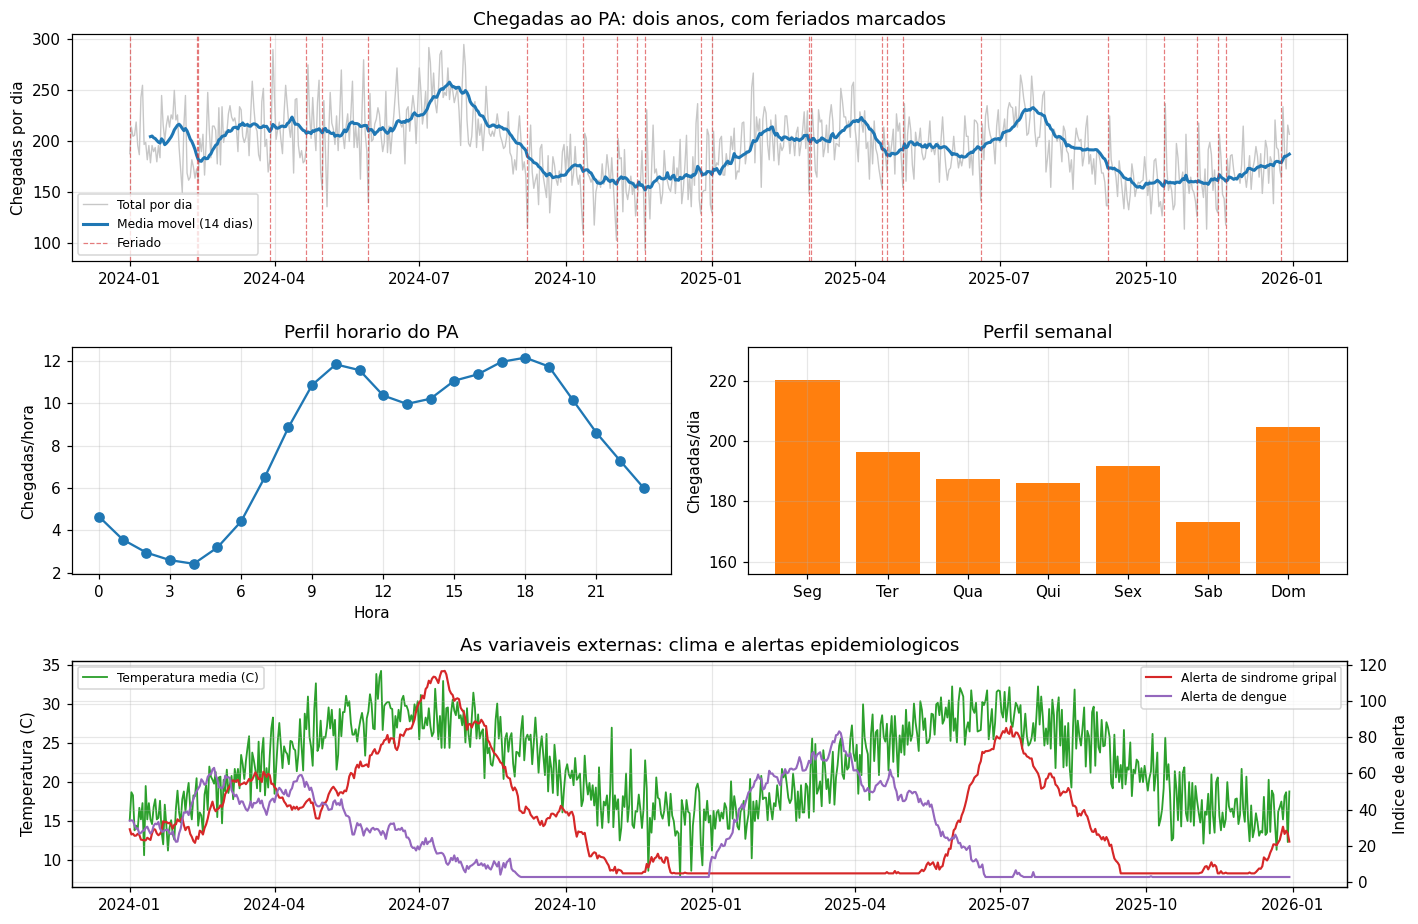

Hora de pico   : 18h com 12.1 chegadas/hora
Hora mais calma: 4h com 2.4 chegadas/hora
Dia mais cheio : Seg (220/dia)  |  mais leve: Sab (173/dia)


In [3]:
fig = plt.figure(figsize=(13, 8.5))
ax1 = plt.subplot2grid((3, 2), (0, 0), colspan=2)
ax2 = plt.subplot2grid((3, 2), (1, 0))
ax3 = plt.subplot2grid((3, 2), (1, 1))
ax4 = plt.subplot2grid((3, 2), (2, 0), colspan=2)

ax1.plot(diario.index, diario.chegadas, color="#c7c7c7", lw=0.9, label="Total por dia")
ax1.plot(diario.index, diario.chegadas.rolling(14).mean(), color="#1f77b4", lw=2,
         label="Media movel (14 dias)")
for i, f in enumerate(FERIADOS):
    ax1.axvline(f, color="#d62728", ls="--", lw=0.8, alpha=0.6, label="Feriado" if i == 0 else None)
ax1.set_title("Chegadas ao PA: dois anos, com feriados marcados")
ax1.set_ylabel("Chegadas por dia"); ax1.legend(fontsize=8)

perfil_h = movimento.chegadas.groupby(movimento.index.hour).mean()
ax2.plot(perfil_h.index, perfil_h.values, marker="o", color="#1f77b4")
ax2.set_title("Perfil horario do PA"); ax2.set_xlabel("Hora"); ax2.set_ylabel("Chegadas/hora")
ax2.set_xticks(range(0, 24, 3))

nomes = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sab", "Dom"]
perfil_d = diario.chegadas.groupby(diario.index.dayofweek).mean()
ax3.bar(nomes, perfil_d.values, color="#ff7f0e")
ax3.set_title("Perfil semanal"); ax3.set_ylabel("Chegadas/dia")
ax3.set_ylim(perfil_d.min() * 0.9, perfil_d.max() * 1.05)

ax4.plot(externas.index, externas.temp_media, color="#2ca02c", lw=1.2, label="Temperatura media (C)")
ax4b = ax4.twinx()
ax4b.plot(externas.index, externas.alerta_gripe, color="#d62728", lw=1.4, label="Alerta de sindrome gripal")
ax4b.plot(externas.index, externas.alerta_dengue, color="#9467bd", lw=1.4, label="Alerta de dengue")
ax4.set_title("As variaveis externas: clima e alertas epidemiologicos")
ax4.set_ylabel("Temperatura (C)"); ax4b.set_ylabel("Indice de alerta")
ax4.legend(loc="upper left", fontsize=8); ax4b.legend(loc="upper right", fontsize=8)

plt.tight_layout(); plt.show()

print(f"Hora de pico   : {perfil_h.idxmax()}h com {perfil_h.max():.1f} chegadas/hora")
print(f"Hora mais calma: {perfil_h.idxmin()}h com {perfil_h.min():.1f} chegadas/hora")
print(f"Dia mais cheio : {nomes[int(perfil_d.idxmax())]} ({perfil_d.max():.0f}/dia)  |  "
      f"mais leve: {nomes[int(perfil_d.idxmin())]} ({perfil_d.min():.0f}/dia)")

> **Lendo os gráficos.** Quatro retratos do problema.
>
> **No topo**, os dois anos de total diário. A média móvel sobe e desce em ondas de semanas, e as linhas vermelhas dos feriados caem quase sempre sobre **vales**. Já dá para suspeitar de duas famílias de variáveis: calendário e alguma coisa sazonal e lenta.
>
> **No meio à esquerda**, o perfil horário clássico de pronto atendimento: vale profundo entre 3h e 5h (cerca de **2,5 chegadas/hora**), subida ao longo da manhã, leve queda no meio da tarde e **pico no início da noite, às 18h** (cerca de **12,1 chegadas/hora**). São mais de quatro vezes de diferença entre o vale e o pico, e é por isso que a escala do PA não pode ser uniforme.
>
> **No meio à direita**, o perfil semanal: **segunda-feira é o dia mais cheio** e **sábado o mais leve**. O padrão é conhecido na literatura e tem explicação operacional: parte da demanda de sábado e domingo é adiada e chega na segunda, somada ao que a atenção primária não absorveu no fim de semana.
>
> **Embaixo**, as variáveis externas. A temperatura desenha a onda anual; os alertas epidemiológicos têm **forma sazonal mais um componente errático**, com surtos que sobem e descem fora de hora. É esse componente errático que vai permitir descobrir as defasagens mais adiante: se os alertas fossem perfeitamente sazonais, seriam indistinguíveis de uma variável de calendário.


## 11.1 Features temporais

A primeira família é a mais barata de todas: sai **de graça do índice de tempo**, sem nenhuma fonte de dados adicional. E, como veremos na ablação, ela é a que carrega mais informação por unidade de esforço.

| Feature              | O que captura                                                                   |
| -------------------- | ------------------------------------------------------------------------------- |
| `hora`               | o perfil intradiário do PA                                                      |
| `dia_semana`         | segunda cheia, sábado leve                                                      |
| `mes` e `dia_do_ano` | sazonalidade anual (inverno respiratório, verão de arboviroses)                 |
| `dia_mes`            | efeitos de calendário de pagamento e de ciclo administrativo                    |
| `semana_mes`         | relevante na operadora, onde o início do mês concentra renovações e vencimentos |
| `eh_fim_semana`      | quebra binária simples que qualquer modelo aproveita                            |

Antes de escrever a coluna, vale **olhar se o efeito existe**. Feature engineering não é adicionar tudo que se consegue imaginar: cada variável inútil é ruído a mais para o modelo separar do sinal, e uma linha a mais para manter em produção.


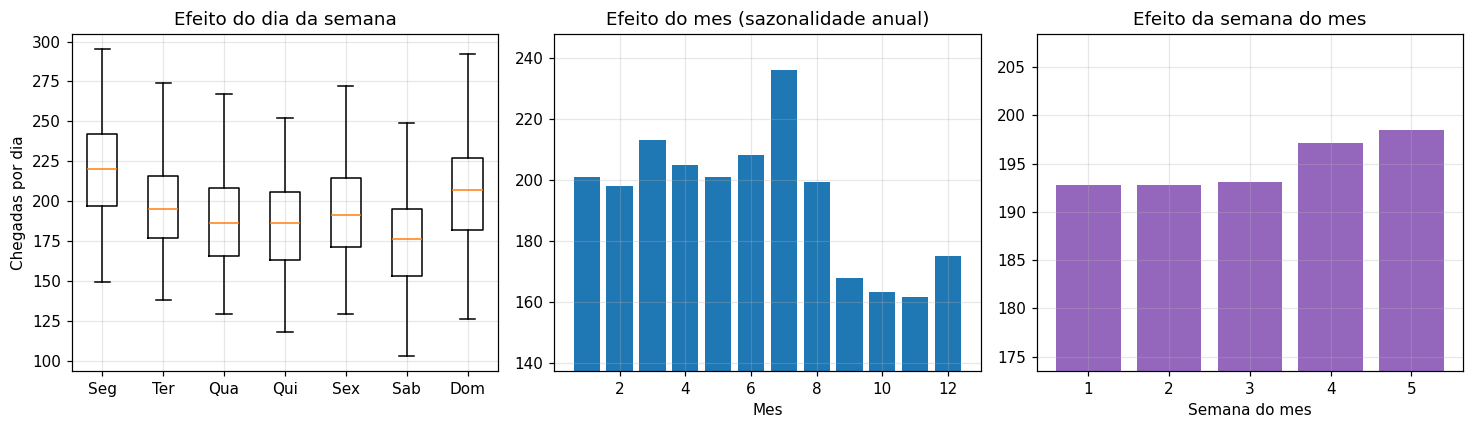

Amplitude do efeito, em % da media diaria:
  dia da semana :  24.3%   (de 173 a 220 chegadas)
  mes do ano    :  38.4%   (de 162 a 236)
  semana do mes :   2.9%   <- praticamente nulo neste problema


In [4]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13.5, 4))

dados_dsem = [diario.chegadas[diario.index.dayofweek == k].values for k in range(7)]
ax1.boxplot(dados_dsem, tick_labels=nomes, showfliers=False)
ax1.set_title("Efeito do dia da semana"); ax1.set_ylabel("Chegadas por dia")

por_mes = diario.chegadas.groupby(diario.index.month).mean()
ax2.bar(por_mes.index, por_mes.values, color="#1f77b4")
ax2.set_title("Efeito do mes (sazonalidade anual)")
ax2.set_xlabel("Mes"); ax2.set_ylim(por_mes.min() * 0.85, por_mes.max() * 1.05)

por_semana_mes = diario.chegadas.groupby((diario.index.day - 1) // 7 + 1).mean()
ax3.bar(por_semana_mes.index, por_semana_mes.values, color="#9467bd")
ax3.set_title("Efeito da semana do mes")
ax3.set_xlabel("Semana do mes"); ax3.set_ylim(por_semana_mes.min() * 0.9, por_semana_mes.max() * 1.05)

plt.tight_layout(); plt.show()

amplitude = lambda s: 100 * (s.max() - s.min()) / s.mean()
print(f"Amplitude do efeito, em % da media diaria:")
print(f"  dia da semana : {amplitude(perfil_d):5.1f}%   (de {perfil_d.min():.0f} a {perfil_d.max():.0f} chegadas)")
print(f"  mes do ano    : {amplitude(por_mes):5.1f}%   (de {por_mes.min():.0f} a {por_mes.max():.0f})")
print(f"  semana do mes : {amplitude(por_semana_mes):5.1f}%   <- praticamente nulo neste problema")

> **Lendo os gráficos.** O teste é simples: **a variável separa a distribuição?**
>
> - O **dia da semana** separa bem: a amplitude entre o menor e o maior dia é de **24,3% da média diária** (de 173 chegadas no sábado a 220 na segunda), e as caixas dos dois extremos quase não se sobrepõem. Vale a coluna.
> - O **mês** separa ainda mais, com amplitude de **38,4%** (de 162 a 236 chegadas), com o pico no inverno. Vale a coluna, embora parte desse efeito seja consequência do clima e da epidemia, que vamos medir diretamente depois.
> - A **semana do mês** é quase plana, com amplitude de **2,9%**. **Não vale a coluna**, pelo menos não neste problema. Guarde a variável para o notebook da operadora, onde ela é relevante (vencimento de mensalidade e ciclo de faturamento concentram demanda no início do mês). Este contraste é o ponto: **não existe lista universal de features boas**, existe lista boa para um problema específico.


### Como codificar o tempo: ordinal, one-hot ou cíclica

Escrever `hora = 23` parece inofensivo, e não é. Ao entregar a hora como um número de 0 a 23, você está afirmando que **23 está muito longe de 0**, quando na verdade são horas vizinhas. O mesmo vale para dezembro e janeiro, e para domingo e segunda. Existem três formas de resolver isso:

**Ordinal.** Manter o número cru. É o mais simples e funciona bem em **modelos de árvore**, porque a árvore pode fazer cortes em qualquer ponto e reconstruir a estrutura por partes.

**One-hot.** Criar uma coluna binária por valor (24 colunas para a hora). Dá ao modelo **liberdade total**, já que cada hora tem seu próprio coeficiente, ao custo de muitas colunas e de nenhuma informação de vizinhança (o modelo não sabe que 14h fica entre 13h e 15h).

**Cíclica.** Projetar o tempo em um **círculo**, com seno e cosseno:

$$ x*{\sin} = \sin\!\left(\frac{2\pi \cdot \text{hora}}{24}\right) \qquad\qquad x*{\cos} = \cos\!\left(\frac{2\pi \cdot \text{hora}}{24}\right) $$

Duas colunas apenas, e a distância entre 23h e 0h volta a ser pequena, como deve ser. É a codificação padrão para **modelos lineares e redes neurais**.

A pergunta prática é: **isso muda o resultado?** A resposta depende inteiramente do modelo, e vamos medir com um Ridge (linear) e um LightGBM (árvore) lado a lado.


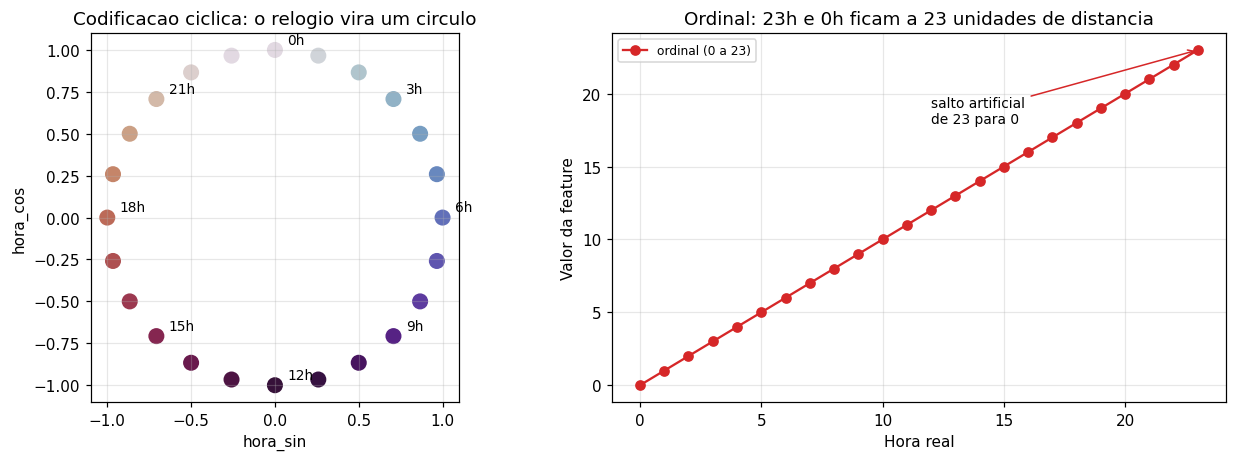

Distancia entre 23h e 0h:
  ordinal : 23.00  (o maior valor possivel, e esta errado)
  ciclica : 0.2611  (identica a distancia entre 0h e 1h, que e 0.2611)


In [5]:
horas = np.arange(24)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))
ax1.scatter(np.sin(2 * np.pi * horas / 24), np.cos(2 * np.pi * horas / 24),
            s=90, c=horas, cmap="twilight")
for h in range(0, 24, 3):
    ax1.annotate(f"{h}h", (np.sin(2 * np.pi * h / 24), np.cos(2 * np.pi * h / 24)),
                 textcoords="offset points", xytext=(8, 4), fontsize=9)
ax1.set_title("Codificacao ciclica: o relogio vira um circulo")
ax1.set_xlabel("hora_sin"); ax1.set_ylabel("hora_cos"); ax1.set_aspect("equal")

ax2.plot(horas, horas, marker="o", color="#d62728", label="ordinal (0 a 23)")
ax2.set_xlabel("Hora real"); ax2.set_ylabel("Valor da feature")
ax2.set_title("Ordinal: 23h e 0h ficam a 23 unidades de distancia")
ax2.annotate("salto artificial\nde 23 para 0", xy=(23, 23), xytext=(12, 18), fontsize=9,
             arrowprops=dict(arrowstyle="->", color="#d62728"))
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"Distancia entre 23h e 0h:")
print(f"  ordinal : {abs(23 - 0):.2f}  (o maior valor possivel, e esta errado)")
d_ciclica = np.hypot(np.sin(2*np.pi*23/24) - np.sin(0), np.cos(2*np.pi*23/24) - np.cos(0))
d_1h = np.hypot(np.sin(2*np.pi*1/24) - np.sin(0), np.cos(2*np.pi*1/24) - np.cos(0))
print(f"  ciclica : {d_ciclica:.4f}  (identica a distancia entre 0h e 1h, que e {d_1h:.4f})")

> **Lendo os gráficos.** À esquerda, o relógio virou circunferência: cada hora é um ponto, e **23h fica coladinha em 0h**, exatamente como deve ser. À direita, a codificação ordinal com o problema explícito: entre 23h e 0h existe um **salto artificial** de 23 unidades, a maior distância possível dentro da variável, aplicada ao par de horas mais próximo que existe.
>
> Os números confirmam: na codificação cíclica, a distância entre 23h e 0h é **0,2611**, idêntica à distância entre 0h e 1h. A geometria ficou correta.
>
> Agora a pergunta que importa: isso muda o erro do modelo?


In [6]:
def montar_diario(diario, externas):
    """Constroi TODAS as features. Os blocos sao selecionados depois, por nome."""
    idx = diario.index
    X = pd.DataFrame(index=idx)

    # --- bloco TEMPORAL
    X["dia_semana"] = idx.dayofweek
    X["mes"] = idx.month
    X["dia_mes"] = idx.day
    X["semana_mes"] = (idx.day - 1) // 7 + 1
    X["eh_fim_semana"] = (idx.dayofweek >= 5).astype(int)
    X["dia_do_ano"] = idx.dayofyear

    # --- bloco CICLICO
    X["dsem_sin"] = np.sin(2 * np.pi * idx.dayofweek / 7)
    X["dsem_cos"] = np.cos(2 * np.pi * idx.dayofweek / 7)
    X["doy_sin"] = np.sin(2 * np.pi * idx.dayofyear / 365)
    X["doy_cos"] = np.cos(2 * np.pi * idx.dayofyear / 365)

    # --- bloco CALENDARIO
    X["eh_feriado"] = np.isin(idx, FERIADOS).astype(int)
    X["eh_vespera"] = np.isin(idx, FERIADOS - pd.Timedelta(days=1)).astype(int)
    X["eh_pos_feriado"] = np.isin(idx, FERIADOS + pd.Timedelta(days=1)).astype(int)
    X["ferias_escolares"] = (((idx.month == 1) | (idx.month == 7)) |
                             ((idx.month == 12) & (idx.day >= 20))).astype(int)

    # --- bloco CLIMA (a defasagem sera justificada na Secao 11.3)
    X["temp_prev"] = externas.temp_media.values          # previsao meteorologica para o dia alvo
    X["chuva_prev"] = externas.chuva_mm.values
    X["temp_lag3"] = externas.temp_media.shift(3).values
    X["graus_frio_lag3"] = np.maximum(0, 19 - X["temp_lag3"])
    X["temp_media7"] = externas.temp_media.shift(1).rolling(7).mean().values

    # --- bloco EPIDEMIOLOGICO
    X["gripe_lag4"] = externas.alerta_gripe.shift(4).values
    X["dengue_lag7"] = externas.alerta_dengue.shift(7).values
    X["gripe_media7"] = externas.alerta_gripe.shift(4).rolling(7).mean().values
    X["dengue_media7"] = externas.alerta_dengue.shift(7).rolling(7).mean().values

    # --- bloco HISTORICO da propria serie (sempre com shift, para nao usar o dia alvo)
    s = diario["chegadas"]
    X["lag1"] = s.shift(1)
    X["lag7"] = s.shift(7)
    X["media7"] = s.shift(1).rolling(7).mean()
    X["media28"] = s.shift(1).rolling(28).mean()
    X["dp7"] = s.shift(1).rolling(7).std()
    return X


BLOCO_TEMPORAL = ["dia_semana", "mes", "dia_mes", "semana_mes", "eh_fim_semana", "dia_do_ano"]
BLOCO_CICLICO = ["dsem_sin", "dsem_cos", "doy_sin", "doy_cos"]
BLOCO_CALENDARIO = ["eh_feriado", "eh_vespera", "eh_pos_feriado", "ferias_escolares"]
BLOCO_CLIMA = ["temp_prev", "chuva_prev", "temp_lag3", "graus_frio_lag3", "temp_media7"]
BLOCO_EPIDEMIA = ["gripe_lag4", "dengue_lag7", "gripe_media7", "dengue_media7"]
BLOCO_HISTORICO = ["lag1", "lag7", "media7", "media28", "dp7"]

X = montar_diario(diario, externas)
y = diario["chegadas"]
intensidade = diario["intensidade"]

completo = X.notna().all(axis=1)
X, y, intensidade = X[completo], y[completo], intensidade[completo]

n = len(X)
c1, c2 = int(0.70 * n), int(0.85 * n)

def metricas(y_real, y_prev):
    y_real = np.asarray(y_real, float); y_prev = np.asarray(y_prev, float)
    erro = y_real - y_prev
    return (np.mean(np.abs(erro)), np.sqrt(np.mean(erro ** 2)),
            np.mean(np.abs(erro / y_real)) * 100)

y_teste = y.iloc[c2:]

def treinar_lgb(colunas, semente=SEMENTE):
    modelo = lgb.LGBMRegressor(n_estimators=3000, learning_rate=0.03, num_leaves=15,
                               min_child_samples=15, subsample=0.8, subsample_freq=1,
                               colsample_bytree=0.8, random_state=semente, verbose=-1)
    modelo.fit(X[colunas].iloc[:c1], y.iloc[:c1],
               eval_set=[(X[colunas].iloc[c1:c2], y.iloc[c1:c2])], eval_metric="l1",
               callbacks=[lgb.early_stopping(100, verbose=False)])
    return modelo, metricas(y_teste, modelo.predict(X[colunas].iloc[c2:]))

def treinar_ridge(colunas):
    escala = StandardScaler().fit(X[colunas].iloc[:c1])
    modelo = Ridge(alpha=1.0).fit(escala.transform(X[colunas].iloc[:c1]), y.iloc[:c1])
    return metricas(y_teste, modelo.predict(escala.transform(X[colunas].iloc[c2:])))

# One-hot do dia da semana e do mes, so para este experimento
onehot = pd.concat([pd.get_dummies(X["dia_semana"], prefix="ds").astype(float),
                    pd.get_dummies(X["mes"], prefix="m").astype(float)], axis=1)
X = pd.concat([X, onehot], axis=1)
COLS_ONEHOT = list(onehot.columns)

comparacao = []
for nome, colunas in [("Ordinal (dia_semana, dia_do_ano)", ["dia_semana", "dia_do_ano"]),
                      ("Ciclica (4 colunas sin/cos)", BLOCO_CICLICO),
                      (f"One-hot ({len(COLS_ONEHOT)} colunas)", COLS_ONEHOT)]:
    comparacao.append({"codificacao": nome,
                       "MAE Ridge (linear)": round(treinar_ridge(colunas)[0], 2),
                       "MAE LightGBM (arvore)": round(treinar_lgb(colunas)[1][0], 2)})
pd.DataFrame(comparacao)

,codificacao,MAE Ridge (linear),MAE LightGBM (arvore)
0,"Ordinal (dia_semana, dia_do_ano)",24.44,22.05
1,Ciclica (4 colunas sin/cos),20.17,21.11
2,One-hot (19 colunas),16.70,22.06


> **Lendo a tabela.** Este é um dos resultados mais úteis do notebook, porque desfaz um mito comum.
>
> **Para o modelo linear (Ridge), a codificação muda tudo.** O MAE cai de **24,44** com a codificação ordinal para **20,17** com a cíclica e para **16,70** com one-hot. São **32% de melhora** apenas por reescrever a mesma informação de outra forma. E faz sentido: um Ridge com `dia_semana` ordinal é obrigado a assumir que o efeito **cresce linearmente** de segunda a domingo, o que é falso. A codificação cíclica permite uma onda; o one-hot permite qualquer formato.
>
> **Para a árvore (LightGBM), praticamente não muda nada**: 22,05, 21,11 e 22,06, diferenças dentro do ruído. A razão é estrutural: a árvore pode cortar `dia_semana <= 4.5` e depois `dia_semana <= 1.5`, reconstruindo qualquer formato sem ajuda nenhuma.
>
> A conclusão prática, que vale escrever na parede:
>
> | Modelo                           | A codificação do tempo importa?                                |
> | -------------------------------- | -------------------------------------------------------------- |
> | Regressão linear, Ridge, Lasso   | **Muito.** Use cíclica ou one-hot                              |
> | Redes neurais                    | **Muito.** Use cíclica (foi o que fizemos no notebook de LSTM) |
> | Árvores, Random Forest, boosting | **Quase nada.** Ordinal já serve                               |
>
> Note também a inversão de posições: o one-hot, que é disparado o melhor no Ridge, **empata com a codificação ordinal** no LightGBM (22,06 contra 22,05), enquanto a cíclica fica marginalmente à frente. Espalhar a informação em 19 colunas binárias não ajuda uma árvore, apenas a obriga a gastar mais divisões para chegar ao mesmo lugar. **Não existe boa codificação em abstrato**, existe boa codificação para um modelo.


## 11.2 Features de calendário e feriados

Feriados alteram o padrão de chegada de forma sistemática, e o efeito **não é único**: é uma sequência de três dias com sinais diferentes. Muita equipe modela apenas `eh_feriado` e perde a parte mais cara da história.

- **Véspera:** parte da demanda eletiva é antecipada ou adiada, e o volume cai um pouco.
- **Feriado:** a queda é forte, porque consultório, ambulatório e atenção primária estão fechados, mas parte da demanda migra para o PA. O saldo continua negativo.
- **Dia seguinte:** **a demanda represada aparece**. O volume sobe acima do normal, e é o dia que costuma quebrar a escala, porque ninguém escalou reforço para "o dia depois do feriado".

Vale medir os três efeitos antes de decidir quais colunas criar.


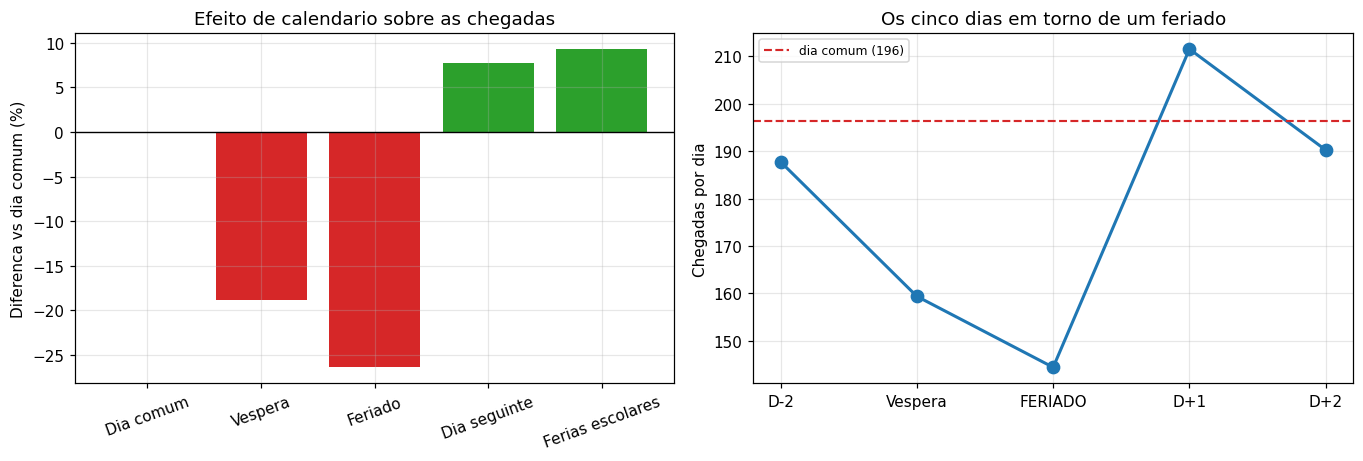

,tipo de dia,dias,media de chegadas,diferenca vs dia comum (%)
0,Dia comum,631,196.3,0.0
1,Vespera,25,159.4,-18.8
2,Feriado,25,144.4,-26.4
3,Dia seguinte,25,211.5,7.7
4,Ferias escolares,119,214.5,9.3


In [7]:
tipos = {
    "Dia comum": ~(X["eh_feriado"] | X["eh_vespera"] | X["eh_pos_feriado"]).astype(bool),
    "Vespera": X["eh_vespera"].astype(bool),
    "Feriado": X["eh_feriado"].astype(bool),
    "Dia seguinte": X["eh_pos_feriado"].astype(bool),
    "Ferias escolares": X["ferias_escolares"].astype(bool),
}
media_comum = y[tipos["Dia comum"]].mean()
resumo = pd.DataFrame([{"tipo de dia": k, "dias": int(v.sum()),
                        "media de chegadas": round(y[v].mean(), 1),
                        "diferenca vs dia comum (%)": round(100 * (y[v].mean() - media_comum) / media_comum, 1)}
                       for k, v in tipos.items()])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.3))
cores = ["#7f7f7f" if abs(v) < 2 else ("#d62728" if v < 0 else "#2ca02c")
         for v in resumo["diferenca vs dia comum (%)"]]
ax1.bar(resumo["tipo de dia"], resumo["diferenca vs dia comum (%)"], color=cores)
ax1.axhline(0, color="black", lw=0.9)
ax1.set_title("Efeito de calendario sobre as chegadas")
ax1.set_ylabel("Diferenca vs dia comum (%)")
ax1.tick_params(axis="x", rotation=20)

# O perfil dos 5 dias em torno de um feriado
janela = range(-2, 3)
medias = []
for delta in janela:
    datas = pd.DatetimeIndex([f + pd.Timedelta(days=delta) for f in FERIADOS])
    medias.append(y[y.index.isin(datas)].mean())
ax2.plot(list(janela), medias, marker="o", ms=8, color="#1f77b4", lw=2)
ax2.axhline(media_comum, color="#d62728", ls="--", lw=1.4, label=f"dia comum ({media_comum:.0f})")
ax2.set_xticks(list(janela))
ax2.set_xticklabels(["D-2", "Vespera", "FERIADO", "D+1", "D+2"])
ax2.set_title("Os cinco dias em torno de um feriado")
ax2.set_ylabel("Chegadas por dia"); ax2.legend(fontsize=8)

plt.tight_layout(); plt.show()
resumo

> **Lendo os gráficos.** O painel da direita conta a história inteira em uma curva. O volume vem no patamar normal em D-2, **cai na véspera**, **despenca no feriado** e **salta acima do normal no dia seguinte**, antes de voltar ao normal em D+2. É exatamente a sequência que a operação sente e que uma única variável `eh_feriado` não descreve.
>
> Os números da tabela quantificam: a véspera tem **18,8% menos** chegadas do que um dia comum, o feriado tem **26,4% menos**, e o **dia seguinte tem 7,7% mais**. Para um PA que recebe 196 pacientes em um dia comum, esses 7,7% são **15 pacientes a mais** concentrados em um dia para o qual ninguém escalou reforço, logo depois de dois dias de equipe reduzida.
>
> As **férias escolares** aparecem com **9,3% a mais**, um efeito maior do que se poderia supor e que compensa a coluna. Ainda assim, guarde uma ressalva: janeiro e julho também são meses de férias **da equipe**, e parte desse efeito pode estar capturando sazonalidade anual em vez do fenômeno pediátrico. Mais adiante a importância por permutação dirá se a variável ganhou o seu lugar depois de o modelo já conhecer o mês.
>
> **Na prática**, o calendário brasileiro tem mais camadas do que as quatro que usamos: feriados **estaduais e municipais** (que mudam por cidade e afetam o PA local), pontos facultativos, **emendas e pontes**, e eventos regionais. Vale a pena manter uma tabela de calendário versionada, e não uma lista de datas escrita no meio do código.


## 11.3 Clima e epidemiologia: o problema da defasagem

Aqui está o ponto mais técnico da aula, e o que separa uma engenharia de variáveis amadora de uma profissional.

Temperatura, chuva e alertas epidemiológicos afetam a chegada ao PA, mas **não afetam no mesmo dia**. Uma frente fria não enche o pronto atendimento na hora em que chega: ela adoece a população, os quadros respiratórios evoluem, e a procura aparece **alguns dias depois**. Um alerta de dengue reflete casos notificados, que já vinham incubando, e o efeito sobre o PA aparece com atraso ainda maior.

Se você juntar a temperatura do dia com as chegadas do dia, vai medir a coisa errada. A pergunta correta é: **qual defasagem usar?**

A ferramenta natural é a **correlação cruzada**: correlacionar a série de chegadas com a variável externa deslocada em $k$ dias, para vários valores de $k$, e escolher o $k$ de maior correlação em módulo. Vamos fazer isso do jeito ingênuo primeiro.


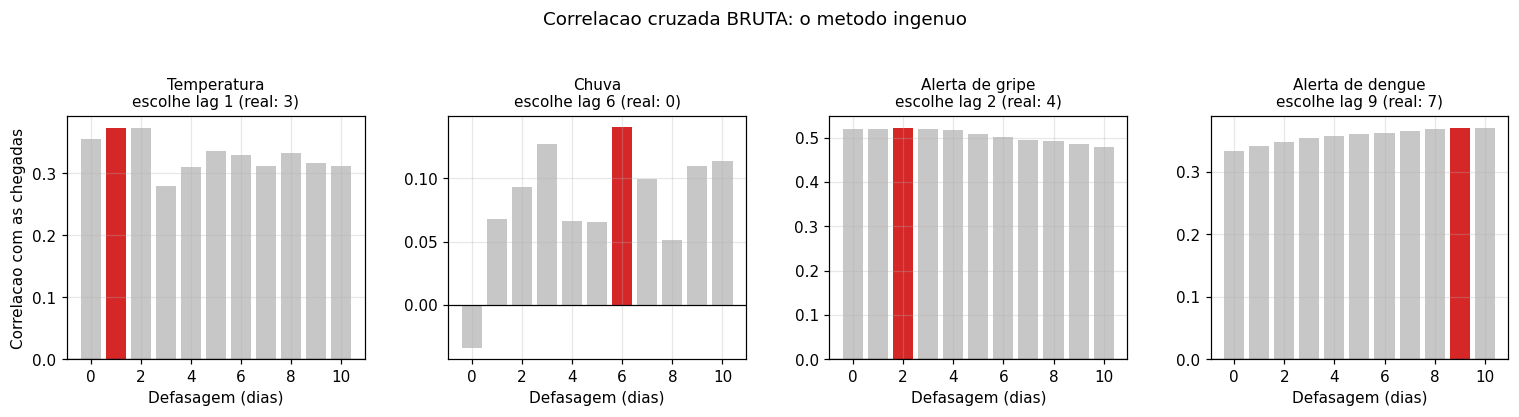

,variavel,defasagem escolhida,defasagem verdadeira,correlacao,acertou
0,Temperatura,1,3,0.374,False
1,Chuva,6,0,0.140,False
2,Alerta de gripe,2,4,0.522,False
3,Alerta de dengue,9,7,0.370,False


In [8]:
# Para a analise exploratoria usamos a serie COMPLETA (730 dias), e nao a recortada pelas janelas
serie_diaria = diario["chegadas"]
externas_alinhadas = externas.reindex(serie_diaria.index)

def correlacao_cruzada(alvo, externa, max_lag=10):
    saida = []
    for k in range(max_lag + 1):
        a = alvo.values[k:] if k else alvo.values
        b = externa.values[:len(externa) - k] if k else externa.values
        saida.append(float(np.corrcoef(a, b)[0, 1]))
    return np.array(saida)

VARIAVEIS = [("temp_media", "Temperatura", LAG_TEMPERATURA),
             ("chuva_mm", "Chuva", 0),
             ("alerta_gripe", "Alerta de gripe", LAG_GRIPE),
             ("alerta_dengue", "Alerta de dengue", LAG_DENGUE)]

fig, eixos = plt.subplots(1, 4, figsize=(14, 3.6), sharex=True)
linhas_bruto = []
for ax, (coluna, titulo, verdadeiro) in zip(eixos, VARIAVEIS):
    cc = correlacao_cruzada(serie_diaria, externas_alinhadas[coluna])
    escolhido = int(np.argmax(np.abs(cc)))
    linhas_bruto.append({"variavel": titulo, "defasagem escolhida": escolhido,
                         "defasagem verdadeira": verdadeiro,
                         "correlacao": round(cc[escolhido], 3), "acertou": escolhido == verdadeiro})
    ax.bar(range(len(cc)), cc, color=["#d62728" if i == escolhido else "#c7c7c7" for i in range(len(cc))])
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(f"{titulo}\nescolhe lag {escolhido} (real: {verdadeiro})", fontsize=10)
    ax.set_xlabel("Defasagem (dias)")
eixos[0].set_ylabel("Correlacao com as chegadas")
plt.suptitle("Correlacao cruzada BRUTA: o metodo ingenuo", y=1.04, fontsize=12)
plt.tight_layout(); plt.show()

pd.DataFrame(linhas_bruto)

> **Lendo o resultado.** O método ingênuo **erra as quatro defasagens**. Ele escolhe 1 dia para a temperatura (o correto é 3), 6 para a chuva (o correto é 0), 2 para a gripe (o correto é 4) e 9 para a dengue (o correto é 7). Nenhum acerto em quatro tentativas.
>
> Pior do que errar o número: ele erra o **sinal**. A correlação da temperatura com as chegadas dá **+0,374**, positiva, sugerindo que "quanto mais quente, mais gente no PA", quando o efeito embutido é exatamente o oposto (frio eleva as chegadas).
>
> A causa é a **sazonalidade compartilhada**, e é um dos erros mais comuns em análise de séries temporais. Todas essas variáveis sobem e descem juntas ao longo do ano: no verão faz calor **e** há dengue **e** chove mais; no inverno faz frio **e** há gripe. Como todas oscilam com o mesmo ciclo anual, **todas correlacionam com todas**, e a correlação bruta mede principalmente essa sazonalidade comum, não a relação causal específica.
>
> A correção é conceitualmente simples: **remover primeiro o que já sabemos explicar** e correlacionar apenas o que sobra.


### A correção: correlacionar os resíduos

Vamos ajustar, tanto nas chegadas quanto em cada variável externa, um modelo simples com **tendência, harmônicos anuais e dia da semana**. O que sobra depois desse ajuste é o **componente idiossincrático** de cada série: os surtos fora de época, as frentes frias atípicas, as chuvas isoladas.

Correlacionar resíduo com resíduo responde a pergunta certa: **quando esta variável se afasta do seu padrão sazonal, em quantos dias as chegadas se afastam do delas?**


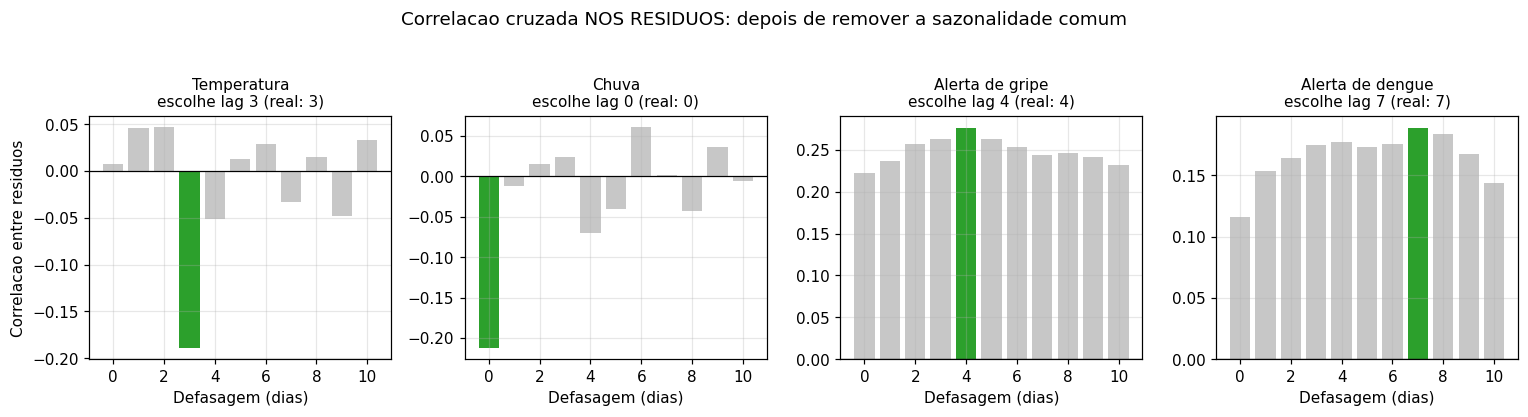

,variavel,defasagem escolhida,defasagem verdadeira,correlacao,acertou
0,Temperatura,3,3,-0.189,True
1,Chuva,0,0,-0.212,True
2,Alerta de gripe,4,4,0.276,True
3,Alerta de dengue,7,7,0.189,True


In [9]:
def matriz_sazonal(indice):
    """Tendencia + 3 harmonicos anuais + dia da semana: o que consideramos 'ja explicado'."""
    t = np.arange(len(indice))
    colunas = [np.ones(len(indice)), t]
    for k in (1, 2, 3):
        colunas += [np.sin(2 * np.pi * k * t / 365), np.cos(2 * np.pi * k * t / 365)]
    colunas += [(indice.dayofweek == k).astype(float) for k in range(6)]
    return np.column_stack(colunas)

BASE = matriz_sazonal(serie_diaria.index)

def residuo_sazonal(valores):
    coef, *_ = np.linalg.lstsq(BASE, np.asarray(valores, float), rcond=None)
    return np.asarray(valores, float) - BASE @ coef

residuo_chegadas = residuo_sazonal(serie_diaria.values)

fig, eixos = plt.subplots(1, 4, figsize=(14, 3.6), sharex=True)
linhas_res = []
for ax, (coluna, titulo, verdadeiro) in zip(eixos, VARIAVEIS):
    r_ext = residuo_sazonal(externas_alinhadas[coluna].values)
    cc = np.array([float(np.corrcoef(residuo_chegadas[k:], r_ext[:len(r_ext) - k] if k else r_ext)[0, 1])
                   for k in range(11)])
    escolhido = int(np.argmax(np.abs(cc)))
    linhas_res.append({"variavel": titulo, "defasagem escolhida": escolhido,
                       "defasagem verdadeira": verdadeiro,
                       "correlacao": round(cc[escolhido], 3), "acertou": escolhido == verdadeiro})
    ax.bar(range(len(cc)), cc, color=["#2ca02c" if i == escolhido else "#c7c7c7" for i in range(len(cc))])
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(f"{titulo}\nescolhe lag {escolhido} (real: {verdadeiro})", fontsize=10)
    ax.set_xlabel("Defasagem (dias)")
eixos[0].set_ylabel("Correlacao entre residuos")
plt.suptitle("Correlacao cruzada NOS RESIDUOS: depois de remover a sazonalidade comum", y=1.04, fontsize=12)
plt.tight_layout(); plt.show()

pd.DataFrame(linhas_res)

> **Lendo o resultado.** **Quatro acertos em quatro.** O método encontra 3 dias para a temperatura, 0 para a chuva, 4 para a gripe e 7 para a dengue, exatamente as defasagens embutidas no gerador.
>
> E os **sinais agora fazem sentido clínico**: a temperatura aparece com correlação **negativa** (**-0,189**), ou seja, queda de temperatura três dias atrás significa mais chegadas hoje; a chuva aparece **negativa no mesmo dia** (**-0,212**), consistente com a ideia de que chuva forte segura a procura por atendimento não urgente; gripe (**+0,276**) e dengue (**+0,189**) aparecem positivas, com 4 e 7 dias de atraso.
>
> Repare também na **forma** dos gráficos, que é informativa por si só. O pico da temperatura é **estreito e nítido**, porque a temperatura tem variação diária forte: dá para separar o dia 3 do dia 2. Já os picos dos alertas epidemiológicos são **largos e achatados**: como o alerta muda devagar, o valor de 4 dias atrás é quase igual ao de 5, e o método distingue mal defasagens vizinhas. Isso é honesto e importante: **em séries suaves, a defasagem exata é pouco identificável**, e a consequência prática é que errar por um ou dois dias ali custa pouco.
>
> Uma nota de método: correlação **não é causalidade**, e este procedimento não prova relação causal nenhuma. O que ele faz é apontar uma defasagem plausível para ser testada. A decisão final é da validação, e é o que fazemos agora.


In [10]:
BLOCO_EXTERNO = BLOCO_TEMPORAL + BLOCO_CALENDARIO + BLOCO_CLIMA + BLOCO_EPIDEMIA

X_original = X.copy()
_, m_correto = treinar_lgb(BLOCO_EXTERNO)

# Versao com TUDO no mesmo dia (defasagem zero), o erro classico
X_zero = X.copy()
ext = externas.reindex(X.index)
X_zero["temp_lag3"] = ext.temp_media.values
X_zero["graus_frio_lag3"] = np.maximum(0, 19 - ext.temp_media.values)
X_zero["gripe_lag4"] = ext.alerta_gripe.values
X_zero["dengue_lag7"] = ext.alerta_dengue.values
X_zero["gripe_media7"] = externas.alerta_gripe.rolling(7).mean().reindex(X.index).values
X_zero["dengue_media7"] = externas.alerta_dengue.rolling(7).mean().reindex(X.index).values

X = X_zero
_, m_zero = treinar_lgb(BLOCO_EXTERNO)
X = X_original

# Versao sem clima e sem epidemiologia
_, m_sem = treinar_lgb(BLOCO_TEMPORAL + BLOCO_CALENDARIO)

pd.DataFrame([
    {"configuracao": "Sem clima e sem epidemiologia", "MAE": round(m_sem[0], 2),
     "RMSE": round(m_sem[1], 2), "MAPE (%)": round(m_sem[2], 2)},
    {"configuracao": "Com clima e epidemiologia, defasagem ZERO", "MAE": round(m_zero[0], 2),
     "RMSE": round(m_zero[1], 2), "MAPE (%)": round(m_zero[2], 2)},
    {"configuracao": "Com clima e epidemiologia, defasagem CORRETA", "MAE": round(m_correto[0], 2),
     "RMSE": round(m_correto[1], 2), "MAPE (%)": round(m_correto[2], 2)},
])

,configuracao,MAE,RMSE,MAPE (%)
0,Sem clima e sem epidemiologia,20.53,24.77,13.26
1,"Com clima e epidemiologia, defasagem ZERO",15.04,18.44,9.00
2,"Com clima e epidemiologia, defasagem CORRETA",12.67,16.16,7.56


> **Lendo a tabela.** O experimento fecha o argumento com número.
>
> - **Sem clima e sem epidemiologia**: MAE de **20,53**. É o modelo que só olha o calendário.
> - **Com as variáveis externas, mas com defasagem zero**: **15,04**. As variáveis ajudam bastante mesmo mal defasadas, porque parte da informação sobrevive (o alerta de ontem se parece com o de hoje).
> - **Com as defasagens corretas**: **12,67**. Uma melhora adicional de **16%** em relação à versão mal defasada, sem coletar **nenhum dado novo**. É a mesma informação, escrita na posição certa do tempo.
>
> Traduzindo para a operação: 2,4 pacientes por dia de erro a menos, obtidos por um deslocamento de índice. Esse é o retorno típico de feature engineering bem feita, e é o motivo de esta aula existir.
>
> Uma observação metodológica importante: fizemos este teste **sem o bloco de histórico da própria série**. Quando as defasagens da série entram no modelo (`lag1`, `media7`), elas capturam boa parte do estado epidemiológico de forma indireta, e o efeito da defasagem errada fica mascarado. Para **medir** o valor de uma variável, é preciso isolá-la das outras que carregam a mesma informação.


### Lags e janelas móveis: a armadilha do `shift`

O bloco mais produtivo de features em previsão costuma ser o **histórico da própria série**: o valor de ontem, o da semana passada, a média dos últimos 7 dias, o desvio-padrão dos últimos 7 dias.

E é justamente aqui que mora o erro mais comum e mais grave de toda a feature engineering. Compare as duas linhas:

```python
X["media7"] = s.rolling(7).mean()             # ERRADO: inclui o proprio dia alvo
X["media7"] = s.shift(1).rolling(7).mean()    # CERTO: so ate o dia anterior
```

A primeira calcula a média dos 7 dias **terminando no dia que queremos prever**, ou seja, inclui a resposta dentro da pergunta. O modelo aprende a confiar nela, a avaliação fica ótima, e em produção a feature **não existe**, porque no momento da previsão o dia ainda não terminou.

A célula abaixo torna o problema visível linha a linha.


In [11]:
demo = pd.DataFrame({"chegadas": y.iloc[:8].values}, index=y.index[:8])
demo["media3_ERRADA"] = demo["chegadas"].rolling(3).mean().round(1)
demo["media3_CORRETA"] = demo["chegadas"].shift(1).rolling(3).mean().round(1)
demo["lag1"] = demo["chegadas"].shift(1)

print("Repare na terceira linha: a media ERRADA ja 'sabe' o valor do proprio dia.\n")
print(demo.to_string())
print()
corr_errada = y.rolling(3).mean().corr(y)
corr_correta = y.shift(1).rolling(3).mean().corr(y)
print(f"Correlacao da media movel de 3 dias com o ALVO:")
print(f"  versao ERRADA  (sem shift): {corr_errada:.3f}   <- altissima, porque contem o alvo")
print(f"  versao CORRETA (com shift): {corr_correta:.3f}   <- informativa, e honesta")

Repare na terceira linha: a media ERRADA ja 'sabe' o valor do proprio dia.

            chegadas  media3_ERRADA  media3_CORRETA   lag1
2024-01-29       250            NaN             NaN    NaN
2024-01-30       221            NaN             NaN  250.0
2024-01-31       226          232.3             NaN  221.0
2024-02-01       194          213.7           232.3  226.0
2024-02-02       172          197.3           213.7  194.0
2024-02-03       150          172.0           197.3  172.0
2024-02-04       215          179.0           172.0  150.0
2024-02-05       245          203.3           179.0  215.0

Correlacao da media movel de 3 dias com o ALVO:
  versao ERRADA  (sem shift): 0.794   <- altissima, porque contem o alvo
  versao CORRETA (com shift): 0.565   <- informativa, e honesta


> **Lendo o resultado.** Na tabela, olhe a coluna `media3_ERRADA` e compare com `chegadas` na mesma linha: a média de três dias **termina no próprio dia**, então um terço do valor que queremos prever já está lá dentro. A versão correta, com `shift(1)`, usa apenas dias anteriores.
>
> A correlação com o alvo mostra o tamanho do problema: **0,794** para a versão errada contra **0,565** para a correta. Aquela diferença de 0,23 é **puro vazamento**, e o modelo vai persegui-la com entusiasmo.
>
> Três regras práticas que evitam a maior parte dos acidentes:
>
> 1. **Toda janela móvel começa com `shift`.** Sem exceção. Se a sua janela não tem um `shift` antes do `rolling`, ela está errada até prova em contrário.
> 2. **Em painel, o `shift` é dentro do grupo**: `df.groupby("id")["valor"].shift(1)`. Sem o `groupby`, a última linha de uma unidade contamina a primeira da seguinte, como vimos no notebook das carteiras.
> 3. **Pergunte de cada coluna: eu teria este número no momento da previsão?** Se a resposta envolve "bom, no fechamento do dia sim", a coluna está vazada para um modelo que roda de manhã.


## Separação temporal, referências e o piso do problema

Antes de medir qualquer coisa, precisamos das três referências de sempre e do **piso de erro**. Como a chegada ao PA é uma **contagem** gerada por um processo de Poisson, existe um limite matemático de precisão: mesmo conhecendo exatamente a intensidade $\lambda$ de cada dia, o número realizado flutua. Guardamos essa intensidade no gerador, então podemos calcular o piso exatamente.

Para uma variável de Poisson com média $\lambda$, o erro absoluto médio de quem conhece $\lambda$ é aproximadamente $\sqrt{2\lambda/\pi}$. Com $\lambda \approx 194$ chegadas por dia, isso dá cerca de 11 pacientes. É contra esse número que todo o resto deve ser lido.


In [12]:
print(f"TREINO   : {c1:4d} dias  ({X.index[0]:%d/%m/%Y} a {X.index[c1-1]:%d/%m/%Y})")
print(f"VALIDACAO: {c2-c1:4d} dias  ({X.index[c1]:%d/%m/%Y} a {X.index[c2-1]:%d/%m/%Y})")
print(f"TESTE    : {n-c2:4d} dias  ({X.index[c2]:%d/%m/%Y} a {X.index[-1]:%d/%m/%Y})")
print()

referencias = pd.DataFrame([
    {"referencia": "Media historica global", **dict(zip(("MAE", "RMSE", "MAPE (%)"),
        np.round(metricas(y_teste, np.full(len(y_teste), y.iloc[:c1].mean())), 2)))},
    {"referencia": "Mesmo dia da semana anterior (lag 7)", **dict(zip(("MAE", "RMSE", "MAPE (%)"),
        np.round(metricas(y_teste, X["lag7"].iloc[c2:]), 2)))},
    {"referencia": "Media dos ultimos 7 dias", **dict(zip(("MAE", "RMSE", "MAPE (%)"),
        np.round(metricas(y_teste, X["media7"].iloc[c2:]), 2)))},
    {"referencia": "ORACULO (conhece a intensidade)", **dict(zip(("MAE", "RMSE", "MAPE (%)"),
        np.round(metricas(y_teste, intensidade.iloc[c2:]), 2)))},
])
referencias

TREINO   :  491 dias  (29/01/2024 a 02/06/2025)
VALIDACAO:  105 dias  (03/06/2025 a 15/09/2025)
TESTE    :  106 dias  (16/09/2025 a 30/12/2025)



,referencia,MAE,RMSE,MAPE (%)
0,Media historica global,34.88,40.22,23.07
1,Mesmo dia da semana anterior (lag 7),20.23,26.11,12.22
2,Media dos ultimos 7 dias,18.36,23.87,11.17
3,ORACULO (conhece a intensidade),9.60,11.86,5.87


> **Lendo a tabela.** O campo de jogo:
>
> - **Média histórica global**: MAE de **34,88** pacientes por dia, MAPE de 23%. É o que acontece quando a escala é dimensionada por uma taxa média fixa, o input estático que a apostila critica na Seção 13.2.
> - **Mesmo dia da semana anterior**: **20,23**. Já captura o ciclo semanal e melhora bastante.
> - **Média dos últimos 7 dias**: **18,36**, a melhor referência simples. Suaviza o ruído e acompanha o nível recente.
> - **Oráculo**: **9,60**, com MAPE de 5,9%. Este é o piso. Nenhum modelo honesto vai abaixo disso, porque o que resta é a aleatoriedade da chegada de pacientes.
>
> Todo o espaço aproveitável está entre **18,36** e **9,60**, ou seja, **8,76 pacientes** de margem. É essa margem que a feature engineering vai disputar.


## Quanto vale cada bloco de variáveis

Agora a medição central da aula. Vamos treinar o mesmo LightGBM cinco vezes, acrescentando **um bloco de cada vez**, na ordem em que um analista realmente trabalharia: começa com o que sai de graça do índice de tempo, depois o calendário, depois o histórico da própria série, e só então parte para buscar dados externos, que é a etapa que custa dinheiro e integração.


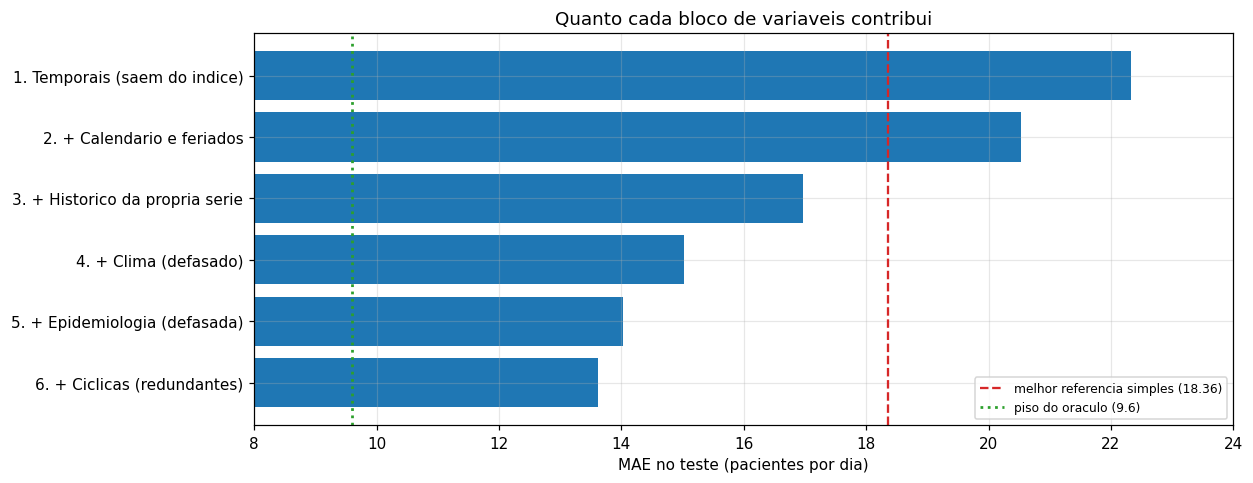

,conjunto,features,MAE,RMSE,MAPE (%),ganho do bloco,% do aproveitavel
0,1. Temporais (saem do indice),6,22.32,26.81,14.57,NaN,0.0%
1,2. + Calendario e feriados,10,20.53,24.77,13.26,1.79,0.0%
2,3. + Historico da propria serie,15,16.97,21.22,10.55,3.56,15.9%
3,4. + Clima (defasado),20,15.03,19.12,9.33,1.94,38.0%
4,5. + Epidemiologia (defasada),24,14.03,17.75,8.41,1.00,49.4%
5,6. + Ciclicas (redundantes),28,13.61,17.22,8.19,0.42,54.2%


In [13]:
ablacao = []
acumulado = []
for nome, bloco in [("1. Temporais (saem do indice)", BLOCO_TEMPORAL),
                    ("2. + Calendario e feriados", BLOCO_CALENDARIO),
                    ("3. + Historico da propria serie", BLOCO_HISTORICO),
                    ("4. + Clima (defasado)", BLOCO_CLIMA),
                    ("5. + Epidemiologia (defasada)", BLOCO_EPIDEMIA),
                    ("6. + Ciclicas (redundantes)", BLOCO_CICLICO)]:
    acumulado = acumulado + bloco
    _, m = treinar_lgb(acumulado)
    ablacao.append({"conjunto": nome, "features": len(acumulado),
                    "MAE": round(m[0], 2), "RMSE": round(m[1], 2), "MAPE (%)": round(m[2], 2)})

ablacao = pd.DataFrame(ablacao)
ablacao["ganho do bloco"] = (-ablacao.MAE.diff()).round(2)
mae_ref, mae_piso = 18.36, 9.60
ablacao["% do aproveitavel"] = ((100 * (mae_ref - ablacao.MAE) / (mae_ref - mae_piso))
                                .round(1).clip(lower=0).astype(str) + "%")

fig, ax = plt.subplots(figsize=(11.5, 4.5))
ax.barh(ablacao["conjunto"][::-1], ablacao["MAE"][::-1], color="#1f77b4")
ax.axvline(mae_ref, color="#d62728", ls="--", lw=1.5, label=f"melhor referencia simples ({mae_ref})")
ax.axvline(mae_piso, color="#2ca02c", ls=":", lw=1.8, label=f"piso do oraculo ({mae_piso})")
ax.set_xlim(8, 24); ax.set_xlabel("MAE no teste (pacientes por dia)")
ax.set_title("Quanto cada bloco de variaveis contribui")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

ablacao

> **Lendo a tabela.** A sequência mostra onde está o dinheiro.
>
> - **Só temporais** (6 features, custo zero): MAE **22,32**. Já é melhor do que a média histórica (34,88), mas ainda **pior do que a média móvel de 7 dias** (18,36). Sozinho, o calendário não basta.
> - **Mais calendário**: **20,53**. Ganho de 1,79 paciente por quatro colunas binárias que saem de uma tabela de feriados. Excelente relação custo e benefício.
> - **Mais histórico da série**: **16,97**. Ganho de **3,56**, o maior de todos, e também de custo zero, porque a informação já estava na própria base. **Este é o bloco que mais rende e o mais esquecido** por quem parte direto para buscar dados externos.
> - **Mais clima**: **15,03**. Ganho de 1,94. Aqui já é preciso integrar uma fonte externa, e o retorno é real.
> - **Mais epidemiologia**: **14,03**. Ganho de 1,00.
> - **Mais cíclicas**: **13,61**. Ganho de 0,42, dentro do ruído. Como já sabemos, para árvores as cíclicas são redundantes com as ordinais.
>
> No total, saímos de 22,32 para 13,61, uma redução de **39%**, e o modelo final captura **54,2%** de todo o espaço aproveitável entre a referência simples e o piso.
>
> Duas lições de gestão de projeto saem daqui. A primeira: **a ordem de trabalho importa**. Os dois blocos mais baratos (temporais e histórico) entregaram a maior parte do ganho, e um projeto que começa negociando acesso à base epidemiológica antes de esgotar o próprio histórico está gastando esforço na ordem errada. A segunda: **cada bloco tem retorno decrescente**, e vale medir antes de contratar. Se a integração com a base de clima custasse seis meses de projeto, o ganho de 1,94 paciente por dia precisaria ser justificado com esse número na mão.


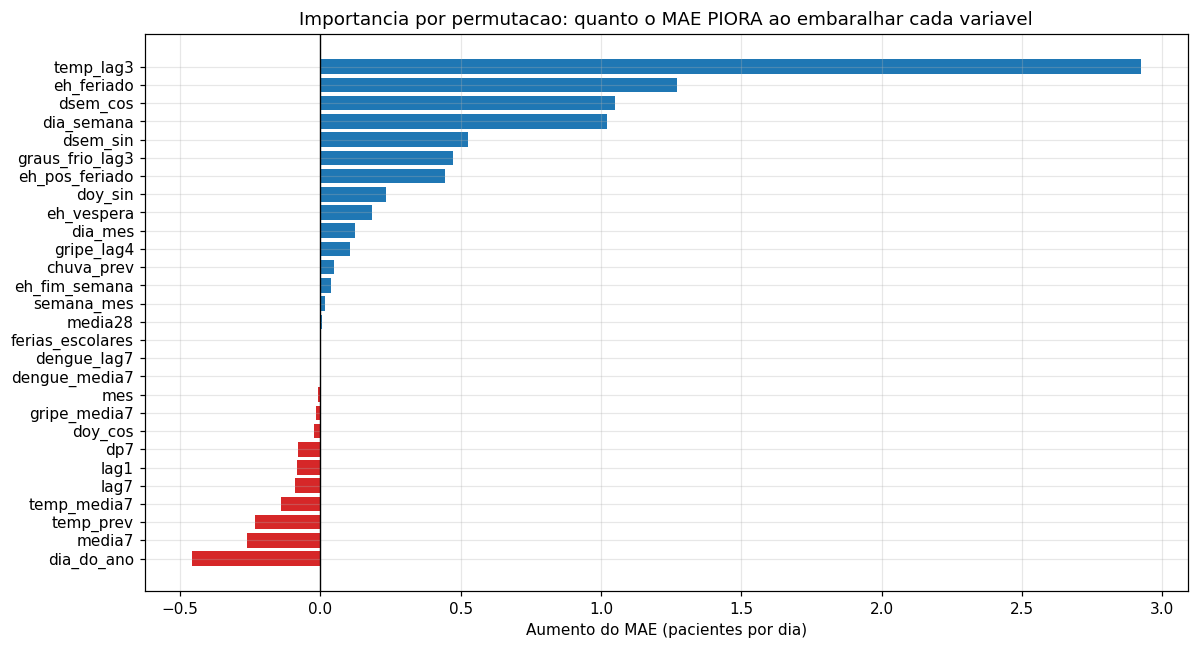

Top 6 variaveis:
temp_lag3          2.923
eh_feriado         1.273
dsem_cos           1.050
dia_semana         1.023
dsem_sin           0.525
graus_frio_lag3    0.471

Variaveis com importancia NEGATIVA (o modelo melhora sem elas):
dia_do_ano     -0.457
media7         -0.262
temp_prev      -0.233
temp_media7    -0.142
lag7           -0.091
lag1           -0.084
dp7            -0.078
doy_cos        -0.024
gripe_media7   -0.016
mes            -0.008


In [14]:
TODAS = acumulado                      # exatamente o conjunto da ultima linha da ablacao
modelo_final, metricas_final = treinar_lgb(TODAS)

resultado = permutation_importance(modelo_final, X[TODAS].iloc[c2:], y_teste,
                                   n_repeats=10, random_state=SEMENTE,
                                   scoring="neg_mean_absolute_error")
importancia = pd.Series(resultado.importances_mean, index=TODAS).sort_values()

fig, ax = plt.subplots(figsize=(11, 6))
cores = ["#d62728" if v < 0 else "#1f77b4" for v in importancia.values]
ax.barh(importancia.index, importancia.values, color=cores)
ax.axvline(0, color="black", lw=0.9)
ax.set_title("Importancia por permutacao: quanto o MAE PIORA ao embaralhar cada variavel")
ax.set_xlabel("Aumento do MAE (pacientes por dia)")
plt.tight_layout(); plt.show()

print("Top 6 variaveis:")
print(importancia.sort_values(ascending=False).head(6).round(3).to_string())
print("\nVariaveis com importancia NEGATIVA (o modelo melhora sem elas):")
print(importancia[importancia < 0].round(3).to_string())

> **Lendo o gráfico.** A **importância por permutação** funciona assim: embaralha-se uma coluna de cada vez no conjunto de teste e mede-se **quanto o erro piora**. É mais confiável do que a importância interna do modelo por duas razões: ela é medida **fora da amostra** e **na métrica que interessa** (aqui, o MAE em pacientes), em vez de em uma unidade interna de ganho.
>
> No topo aparece **`temp_lag3`**, com **+2,92 pacientes** de piora quando embaralhada. A temperatura defasada é, isoladamente, a variável externa mais valiosa do modelo, e ela só ocupa esse lugar porque foi defasada corretamente. Em seguida vêm **`eh_feriado`** (+1,27) e o trio do dia da semana (`dsem_cos`, `dia_semana`, `dsem_sin`).
>
> Agora o detalhe mais instrutivo: **há variáveis com importância negativa**, o que significa que **embaralhá-las melhora o modelo**. `dia_do_ano` (-0,46), `media7` (-0,26) e `temp_prev` (-0,23) estão nessa lista. Isso não quer dizer que sejam prejudiciais em si; quer dizer que são **redundantes** com outras já presentes (o `dia_do_ano` repete o que `mes` e as cíclicas já dizem; `media7` repete o que `lag1` e `media28` já dizem) e que o modelo gastou capacidade ajustando ruído nelas.
>
> A ação prática é testar a remoção. Um conjunto menor de variáveis é mais rápido de treinar, mais barato de manter em produção, menos sujeito a quebra por falha de uma fonte de dados e mais fácil de explicar em auditoria. **Feature engineering também é saber tirar.**


## O teste definitivo de vazamento: ninguém bate o oráculo

Todo projeto de previsão passa por aquele momento em que uma nova variável derruba o erro de forma espetacular e a equipe comemora. Na maior parte das vezes, o que aconteceu foi **vazamento**.

Existe um teste simples e definitivo, e ele é uma das razões de eu insistir tanto no cálculo do piso: **se o modelo bate o oráculo, existe vazamento**. Não é "provavelmente"; é uma impossibilidade estatística. O oráculo conhece a intensidade verdadeira de cada dia, e o que sobra é aleatoriedade de Poisson pura, que ninguém prevê. Um modelo que erra menos do que isso só pode estar lendo a resposta em algum lugar.

Vamos simular o acidente mais comum em base hospitalar: alguém junta uma tabela de **resumo diário** que contém a média de chegadas por hora daquele dia. Parece uma variável de contexto inofensiva.


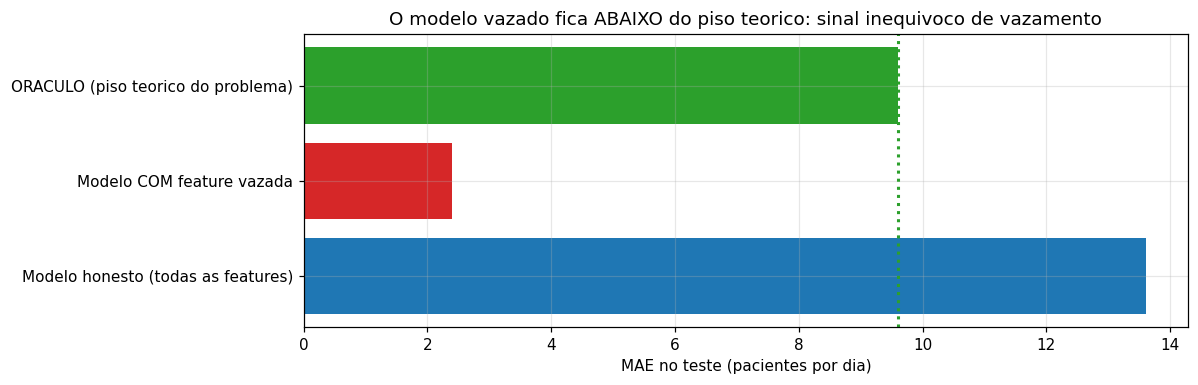

,modelo,MAE,RMSE,MAPE (%)
0,Modelo honesto (todas as features),13.61,17.22,8.19
1,Modelo COM feature vazada,2.39,3.56,1.55
2,ORACULO (piso teorico do problema),9.60,11.86,5.87


In [15]:
X_vazado = X.copy()
X_vazado["media_por_hora_do_dia"] = (y / 24).values      # <- contem o alvo, dividido por 24

X_original = X.copy()
X = X_vazado
_, m_vazado = treinar_lgb(TODAS + ["media_por_hora_do_dia"])
X = X_original

comparacao_vazamento = pd.DataFrame([
    {"modelo": "Modelo honesto (todas as features)", "MAE": round(metricas_final[0], 2),
     "RMSE": round(metricas_final[1], 2), "MAPE (%)": round(metricas_final[2], 2)},
    {"modelo": "Modelo COM feature vazada", "MAE": round(m_vazado[0], 2),
     "RMSE": round(m_vazado[1], 2), "MAPE (%)": round(m_vazado[2], 2)},
    {"modelo": "ORACULO (piso teorico do problema)", "MAE": round(metricas(y_teste, intensidade.iloc[c2:])[0], 2),
     "RMSE": round(metricas(y_teste, intensidade.iloc[c2:])[1], 2),
     "MAPE (%)": round(metricas(y_teste, intensidade.iloc[c2:])[2], 2)},
])

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.barh(comparacao_vazamento.modelo, comparacao_vazamento.MAE,
        color=["#1f77b4", "#d62728", "#2ca02c"])
ax.axvline(metricas(y_teste, intensidade.iloc[c2:])[0], color="#2ca02c", ls=":", lw=2)
ax.set_xlabel("MAE no teste (pacientes por dia)")
ax.set_title("O modelo vazado fica ABAIXO do piso teorico: sinal inequivoco de vazamento")
plt.tight_layout(); plt.show()

comparacao_vazamento

> **Lendo a tabela.** O modelo com a feature vazada erra **2,39 pacientes por dia**, contra 13,61 do modelo honesto. Uma melhora de 82%, com MAPE de 1,6%. Em uma apresentação, isso arrancaria aplausos.
>
> E é **impossível**. O piso do problema é **9,60**, e o modelo vazado está **quatro vezes abaixo** dele. Nenhuma variável do mundo real permite prever o sorteio de Poisson de amanhã; a única explicação é que a resposta estava dentro da entrada.
>
> Guarde este procedimento como rotina de trabalho:
>
> 1. **Estime o piso do seu problema.** Em dados reais você não tem o oráculo, mas quase sempre consegue um limite razoável: para contagens, $\sqrt{2\lambda/\pi}$ é uma boa aproximação; alternativamente, use o erro de um modelo maduro conhecido ou a variabilidade entre réplicas do mesmo dia.
> 2. **Desconfie de qualquer resultado bom demais.** Uma queda súbita e grande de erro, sobretudo depois de acrescentar uma variável, é hipótese de vazamento até prova em contrário.
> 3. **Faça o teste do relógio para cada coluna:** no horário em que o modelo roda em produção, essa informação já existe no sistema? Se a resposta depender do fechamento do dia, do faturamento do mês ou da auditoria posterior, a coluna está vazada.
>
> Vale lembrar o caso do notebook de boosting, em que o _target encoding_ ingênuo melhorou o treino e piorou a validação. Aquele era um vazamento **sutil**, detectável só pela divergência entre treino e validação. Este aqui é **grosseiro** e aparece na comparação com o piso. Um projeto maduro monitora os dois sintomas.


## Da previsão diária para a escala horária

Prevemos o total do dia. A escala, porém, é montada por turno e por hora. A forma mais simples e mais robusta de descer para a hora é a estratégia de **duas etapas**:

$$ \hat{y}_{\text{hora}} = \underbrace{\hat{y}_{\text{dia}}}_{\text{modelo com todas as variáveis}} \times \underbrace{p(\text{hora} \mid \text{dia da semana})}_{\text{perfil intradiário histórico}} $$

O perfil $p$ é a fração média das chegadas do dia que acontece em cada hora, estimado **apenas no treino** e separado por dia da semana (o perfil de sábado não é o de segunda). Ele é uma tabela simples, estável e fácil de auditar.

A pergunta é: isso funciona tão bem quanto modelar hora a hora diretamente? Vamos medir.


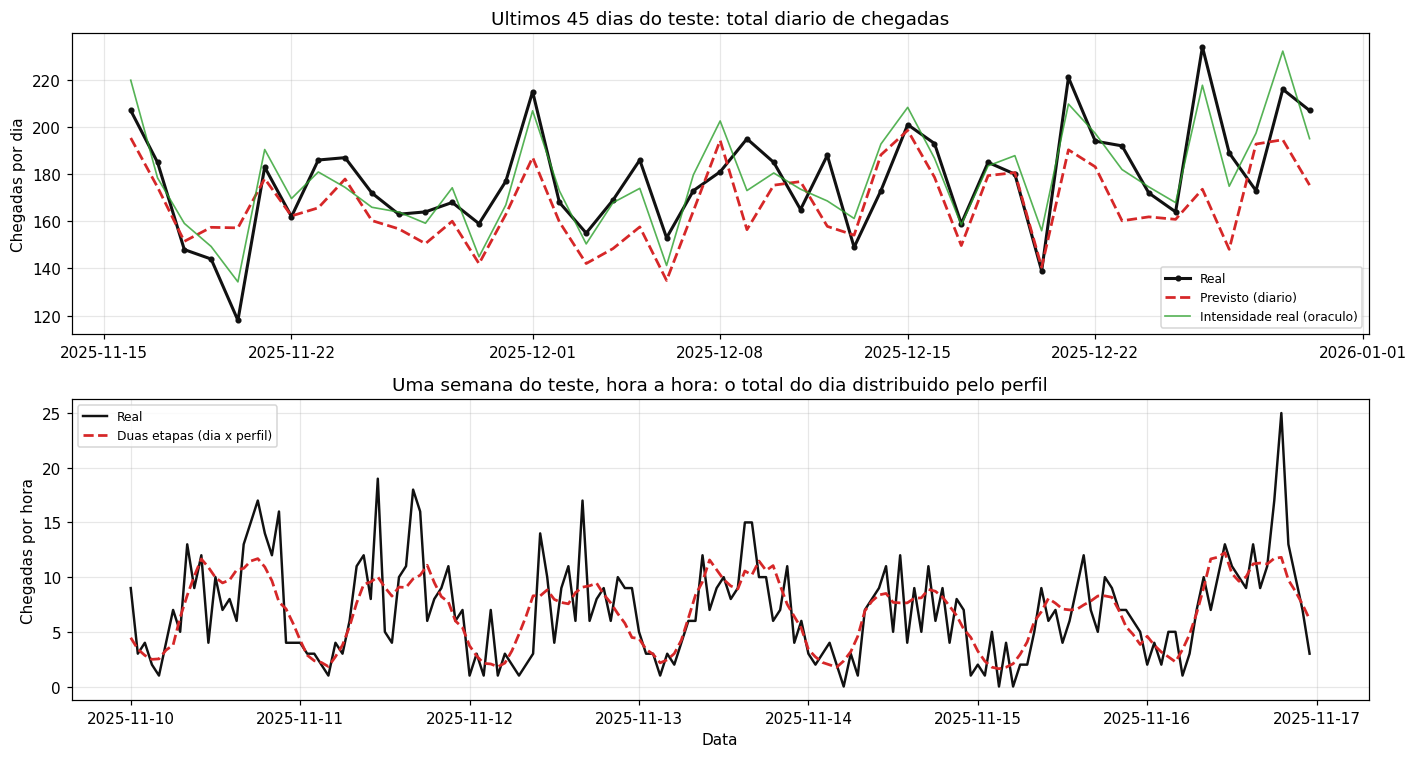

,abordagem,MAE,RMSE
0,Perfil historico puro (sem modelo diario),2.535,3.197
1,Duas etapas (modelo diario x perfil),2.105,2.735
2,ORACULO horario,2.053,2.652


In [16]:
# Perfil intradiario estimado SO no treino
treino_horario = movimento.loc[:X.index[c1 - 1] + pd.Timedelta(hours=23), "chegadas"]
perfil = treino_horario.groupby([treino_horario.index.dayofweek, treino_horario.index.hour]).mean()
perfil = perfil / perfil.groupby(level=0).sum()          # fracao do dia em cada hora

horario_teste = movimento.loc[X.index[c2]:X.index[-1] + pd.Timedelta(hours=23)]
fracao = np.array([perfil.loc[(d, h)] for d, h in
                   zip(horario_teste.index.dayofweek, horario_teste.index.hour)])

previsao_dia = pd.Series(modelo_final.predict(X[TODAS].iloc[c2:]), index=X.index[c2:])
previsao_hora = previsao_dia.reindex(horario_teste.index.normalize()).values * fracao

def metricas_h(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float); e = a - b
    return np.mean(np.abs(e)), np.sqrt(np.mean(e ** 2))

comparacao_h = pd.DataFrame([
    {"abordagem": "Perfil historico puro (sem modelo diario)",
     **dict(zip(("MAE", "RMSE"), np.round(metricas_h(horario_teste.chegadas, y.iloc[:c1].mean() * fracao), 3)))},
    {"abordagem": "Duas etapas (modelo diario x perfil)",
     **dict(zip(("MAE", "RMSE"), np.round(metricas_h(horario_teste.chegadas, previsao_hora), 3)))},
    {"abordagem": "ORACULO horario",
     **dict(zip(("MAE", "RMSE"), np.round(metricas_h(horario_teste.chegadas, horario_teste.intensidade), 3)))},
])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7))
ultimos = previsao_dia.index[-45:]
ax1.plot(ultimos, y.loc[ultimos], color="#111111", lw=2, marker="o", ms=3, label="Real")
ax1.plot(ultimos, previsao_dia.loc[ultimos], color="#d62728", lw=1.8, ls="--", label="Previsto (diario)")
ax1.plot(ultimos, intensidade.loc[ultimos], color="#2ca02c", lw=1.1, alpha=0.8, label="Intensidade real (oraculo)")
ax1.set_title("Ultimos 45 dias do teste: total diario de chegadas")
ax1.set_ylabel("Chegadas por dia"); ax1.legend(fontsize=8)

semana = horario_teste.loc["2025-11-10":"2025-11-16"]
mascara = (horario_teste.index >= "2025-11-10") & (horario_teste.index <= "2025-11-16 23:00")
ax2.plot(semana.index, semana.chegadas, color="#111111", lw=1.6, label="Real")
ax2.plot(semana.index, previsao_hora[mascara], color="#d62728", lw=1.8, ls="--",
         label="Duas etapas (dia x perfil)")
ax2.set_title("Uma semana do teste, hora a hora: o total do dia distribuido pelo perfil")
ax2.set_xlabel("Data"); ax2.set_ylabel("Chegadas por hora"); ax2.legend(fontsize=8)

plt.tight_layout(); plt.show()
comparacao_h

> **Lendo o resultado.** A estratégia de duas etapas alcança **MAE de 2,105 chegadas por hora**, contra um piso horário de **2,053** e contra **2,535** do perfil histórico puro. Ou seja, ela captura quase todo o espaço disponível no nível horário.
>
> Esse resultado merece uma comparação que vale ouro em projeto: um modelo treinado **diretamente na série horária**, com todas as features, chega a um MAE em torno de **2,09** nesta mesma base. A diferença para as duas etapas é de **0,015 chegada por hora**, ou seja, **nenhuma**.
>
> Isso tem consequências práticas grandes:
>
> - **Um modelo em vez de dois.** Você treina no nível diário, onde as variáveis externas atuam e onde há 730 observações em vez de 17.520, e a distribuição horária vira uma tabela de perfil.
> - **Muito mais fácil de explicar.** "Prevemos 210 pacientes amanhã, e historicamente 7% deles chegam entre 18h e 19h" é uma frase que qualquer coordenador de plantão entende e critica. Um modelo horário de caixa fechada não é.
> - **Mais fácil de auditar e corrigir.** Se o perfil mudar (uma reforma que altera o fluxo de entrada, um novo horário de funcionamento da UBS vizinha), você atualiza uma tabela, e não retreina tudo.
>
> No painel de baixo dá para ver o resultado: a curva prevista acompanha o formato do dia e as diferenças de nível entre dias. O que ela não captura são os **picos isolados**, que são os eventos locais e o próprio ruído de Poisson.


## Laboratório interativo: monte o seu conjunto de variáveis

Agora é a sua vez. Ligue e desligue blocos de variáveis e veja o erro responder na hora. O modelo é retreinado a cada mudança.

Experimentos sugeridos:

- **Desligue tudo menos as temporais.** É o ponto de partida de qualquer projeto, e já bate a média histórica.
- **Ligue só o histórico** (`lag1`, `media7`, `media28`). Note que ele sozinho é competitivo, e não custou nenhuma integração de dados.
- **Compare clima ligado com clima desligado.** É a decisão de negócio de contratar ou não uma fonte externa, agora com número.
- **Ligue as cíclicas junto com as temporais.** Veja que quase nada muda, porque para árvores elas são redundantes.


In [17]:
try:
    from ipywidgets import interact, Checkbox
    _INTERATIVO = True
except ImportError:
    _INTERATIVO = False

def laboratorio(temporais=True, ciclicas=False, calendario=True,
                historico=True, clima=True, epidemiologia=True):
    colunas = []
    for ligado, bloco in ((temporais, BLOCO_TEMPORAL), (ciclicas, BLOCO_CICLICO),
                          (calendario, BLOCO_CALENDARIO), (historico, BLOCO_HISTORICO),
                          (clima, BLOCO_CLIMA), (epidemiologia, BLOCO_EPIDEMIA)):
        if ligado:
            colunas += bloco
    if not colunas:
        print("Selecione ao menos um bloco de variaveis.")
        return
    _, m = treinar_lgb(colunas)

    fig, ax = plt.subplots(figsize=(11.5, 4.3))
    ax.barh(["Modelo selecionado"], [m[0]], color="#1f77b4", height=0.45)
    ax.axvline(18.36, color="#d62728", ls="--", lw=1.5, label="melhor referencia simples (18,36)")
    ax.axvline(9.60, color="#2ca02c", ls=":", lw=1.8, label="piso do oraculo (9,60)")
    ax.axvline(13.70, color="#111111", ls="-.", lw=1.2, label="modelo completo (13,70)")
    ax.set_xlim(8, 26); ax.set_xlabel("MAE no teste (pacientes por dia)")
    ax.set_title(f"{len(colunas)} variaveis selecionadas   |   "
                 f"MAE {m[0]:.2f}   RMSE {m[1]:.2f}   MAPE {m[2]:.2f}%")
    ax.legend(fontsize=8, loc="lower right")
    plt.tight_layout(); plt.show()

if _INTERATIVO:
    interact(laboratorio,
             temporais=Checkbox(value=True, description="Temporais"),
             ciclicas=Checkbox(value=False, description="Ciclicas"),
             calendario=Checkbox(value=True, description="Calendario"),
             historico=Checkbox(value=True, description="Historico"),
             clima=Checkbox(value=True, description="Clima"),
             epidemiologia=Checkbox(value=True, description="Epidemiologia"))
else:
    print("ipywidgets indisponivel; exibindo dois cenarios estaticos.")
    laboratorio(True, False, False, False, False, False)
    laboratorio(True, False, True, True, True, True)

interactive(children=(Checkbox(value=True, description='Temporais'), Checkbox(value=False, description='Ciclic…

> **O que observar.** Três experimentos que valem mais do que a leitura da tabela de ablação.
>
> O primeiro é **desligar o histórico** e manter tudo o mais: o erro sobe visivelmente. Aquele bloco de cinco colunas que sai de graça da própria base é o que mais segura o resultado.
>
> O segundo é **ligar apenas temporais e histórico**, sem nenhuma variável externa. Você chega perto do modelo completo com **zero integração de dados**. Esse é o ponto de partida honesto de qualquer proposta: mostre à gestão o que dá para fazer com o que já existe, antes de pedir orçamento para trazer dados de fora.
>
> O terceiro é **ligar as cíclicas** e ver o MAE praticamente não se mover. É a confirmação prática de que uma variável redundante não é uma variável útil.


## Síntese e checklist

Esta aula tratou da etapa que mais rende em previsão de demanda e que menos aparece nos cursos de modelagem.

**O que os números mostraram:**

| Etapa                                        | MAE (pacientes/dia) |
| -------------------------------------------- | ------------------- |
| Média histórica global                       | 34,88               |
| Média dos últimos 7 dias (melhor referência) | 18,36               |
| Só variáveis temporais                       | 22,32               |
| Conjunto completo, bem construído            | **13,61**           |
| Piso do problema (oráculo)                   | 9,60                |
| Modelo com vazamento (impossível)            | 2,39                |

**Checklist de feature engineering, na ordem de trabalho:**

1. **Olhe antes de escrever.** Cada variável candidata deve separar visivelmente a distribuição do alvo. A `semana_mes` não separou nada aqui, e teria sido ruído.
2. **Comece pelo que é de graça.** Índice de tempo e histórico da própria série entregaram a maior parte do ganho, sem nenhuma integração.
3. **Codifique o tempo pensando no modelo.** Cíclica ou one-hot para modelos lineares e redes; ordinal já basta para árvores.
4. **Modele o calendário como sequência.** Véspera, feriado e dia seguinte têm sinais diferentes, e o dia seguinte é o que quebra a escala.
5. **Descubra a defasagem em vez de supor.** E faça isso **nos resíduos**, porque a correlação bruta erra o número e às vezes até o sinal.
6. **Toda janela móvel começa com `shift`.** Em painel, `shift` dentro do grupo.
7. **Meça o valor de cada bloco.** Ablação é barata e informa decisão de investimento em dados.
8. **Use importância por permutação para podar.** Variáveis com importância nula ou negativa são custo de manutenção sem retorno.
9. **Estime o piso e compare.** Bater o piso é prova de vazamento, não de competência.
10. **Escreva um pipeline único.** A mesma função `montar_diario` que gerou o treino tem que gerar a previsão de amanhã. Duas implementações paralelas divergem, e a divergência aparece como erro inexplicável em produção.

**No próximo notebook** trocamos o hospital pela **operadora**. Lá as variáveis deixam de ser clima e epidemia e passam a ser **operacionais**: dia de vencimento da mensalidade, janela de campanha, ciclo de renovação de contrato, categoria e complexidade do procedimento solicitado. Entram também os temas que só aparecem quando o dado é do beneficiário: **codificação de categóricas de alta cardinalidade**, **agregações por entidade**, **governança de dados e LGPD** (Seção 11.5) e a construção de um **pipeline de produção** com monitoramento de desvio de variáveis (Seção 11.6).

---

**Referências**

- Wargon, M. et al. (2009). A systematic review of models for forecasting the number of emergency department visits. _Emergency Medicine Journal_.
- Choudhury, A. (2019). Hourly forecasting of emergency department arrivals: time series analysis.
- Porto, B. M.; Fogliatto, F. S. (2024). Enhanced forecasting of emergency department patient arrivals using feature engineering.
- Sudarshan, V. K. et al. (2021). Performance evaluation of Emergency Department patient arrivals forecasting models.
- Kuhn, M.; Johnson, K. (2019). _Feature Engineering and Selection: A Practical Approach for Predictive Models_. CRC Press.
- Hyndman, R. J.; Athanasopoulos, G. (2021). _Forecasting: Principles and Practice_, 3ª edição.
